Google Colab config

In [ ]:
!pip install pytorch-forecasting
!pip install torch
!pip install pmdarima
!pip install openmeteo-requests requests-cache retry-requests
!pip install holidays
!pip install xgboost
!pip install lightgbm
!pip install joblib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.9/44.9 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 391.5/391.5 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 846.0/846.0 kB 43.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 43.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 849.5/849.5 kB 42.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.4/61.4 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.7/70.7 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 170.8/170.8 kB 12.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 684.7/684.7 kB 33.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.3/144.3 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 394.1/394.1 kB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Import The Libries

In [ ]:
import pandas as pd
import numpy as np
import gc
import pickle
import joblib
import os
import matplotlib.pyplot as plt
import seaborn as sns

import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

import lightning.pytorch as pl
from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer, QuantileLoss, MultiLoss
from pytorch_forecasting.data import GroupNormalizer,MultiNormalizer
from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor, ModelCheckpoint
import torch

from pmdarima import auto_arima

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import openmeteo_requests
import requests_cache
from retry_requests import retry
import datetime
import holidays

import lightgbm as lgb
import xgboost as xgb
from sklearn.model_selection import KFold, TimeSeriesSplit

import warnings
warnings.filterwarnings("ignore")

# Import Data

In [ ]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Research/Training /TFT + SARIMA/Kandy/Kandy_data_training.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30066 entries, 0 to 30065
Data columns (total 51 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Period Start Time                   30066 non-null  object 
 1   AT                                  30066 non-null  float64
 2   RH                                  30066 non-null  float64
 3   BP                                  30066 non-null  float64
 4   Solar Rad                           30066 non-null  float64
 5   Rain Gauge                          30066 non-null  float64
 6   WS Raw                              30066 non-null  float64
 7   O3 Conc                             30066 non-null  float64
 8   CO Conc                             30066 non-null  float64
 9   NO Conc                             30066 non-null  float64
 10  NO2 Conc                            30066 non-null  float64
 11  NOx Conc                            30066

### Fix datetime column

In [ ]:
# Trim whitespace and remove CR/LF
s = df['Period Start Time'].astype(str).str.strip().str.replace(r'[\r\n]', '', regex=True)

# Remove trailing ".000" or other fractional seconds if present
s = s.str.replace(r'\.(\d{1,6})$', r'.\1', regex=True)

# Explicitly remove all fractional seconds:
s_no_ms = s.str.replace(r'\.\d+$', '', regex=True)

# Parsing with milliseconds format first
parsed = pd.to_datetime(s, format='%Y-%m-%d %H:%M:%S.%f', errors='coerce')

# fallback
mask_failed = parsed.isna()
if mask_failed.any():
    parsed.loc[mask_failed] = pd.to_datetime(s_no_ms[mask_failed],
                                             format='%Y-%m-%d %H:%M:%S',
                                             errors='coerce')

df['Period Start Time'] = parsed
print("Remaining unparsable:", df['Period Start Time'].isna().sum())

Remaining unparsable: 0


In [ ]:
df['Period Start Time'] = pd.to_datetime(df['Period Start Time'])

In [ ]:
df = df.set_index('Period Start Time')

### Rename Columns

In [ ]:
df.rename(columns={'PM2.5 Conc': 'PM2 5 Conc',
                   'PM2.5 Conc_lag24': 'PM2 5 Conc_lag24',
                   'PM2.5 Conc_rolling24_mean': 'PM2 5 Conc_rolling24_mean',
                   'PM2.5 Conc_rolling24_std': 'PM2 5 Conc_rolling24_std'}, inplace=True)

# SARIMAX + TFT

## Train SARIMAX Models for All Pollutants

### Slice the Data set

Statistical Model doesn't require many data records to run, so in here I'm using only the last 9000 rows(2024 data). This is relevant because this is the past year's data.

In [ ]:
subset = df.tail(9000).copy()

In [ ]:
subset.shape

(9000, 50)

### Define Targets

In [ ]:
targets = ['PM2 5 Conc', 'PM10 Conc', 'NO2 Conc', 'O3 Conc', 'SO2 Conc']

### Save Models

In [ ]:
save_path = "/content/drive/MyDrive/Colab Notebooks/Research/Training /TFT + SARIMA/Kandy/Intermediates"
os.makedirs(save_path, exist_ok=True)

In [ ]:
# List to store ONLY the lightweight processed data
all_groups_data = []

### Features to use in the models

In [ ]:
features = [
    # Pollutants
    'PM2 5 Conc_lag24',
    'PM2 5 Conc_rolling24_mean',
    'PM10 Conc_lag24',
    'PM10 Conc_rolling24_mean',

    # Weather
    'AT',
    'RH',
    'BP',
    'Rain Gauge',
    'WD_sin', 'WD_cos',

    # Sri Lankan Monsoon
    'monsoon_phase_First Inter-monsoon',
    'monsoon_phase_Northeast Monsoon',
    'monsoon_phase_Second Inter-monsoon',

    # Time & other
    'traffic_hour',
    'is_weekend',
    'is_holiday',
    'month',
    'hour',
    'Heat_Humidity_Interaction'
]

### Model training

In [ ]:
for poll in targets:
    print(poll)

    # Prepare Data
    temp_subset = subset.dropna(subset=[poll])
    y = temp_subset[poll]

    # Log transform (to avoid model predicting negative values)
    y_log = np.log1p(y)

    # Filter features that exist in dataframe
    valid_features = [f for f in features if f in temp_subset.columns]
    X = temp_subset[valid_features].fillna(0)

    # Scale X
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    X_scaled = pd.DataFrame(X_scaled, index=X.index, columns=X.columns)

    # Save the Scaler
    scaler_filename = f"{save_path}/kandy_scaler_{poll.replace(' ', '_')}.pkl"
    joblib.dump(scaler, scaler_filename)
    print("Scaler saved to", scaler_filename)

    # Split the data
    train_size = int(len(subset) * 0.8)

    y_train = y_log.iloc[:train_size]
    y_test = y_log.iloc[train_size:]

    X_train = X_scaled.iloc[:train_size]
    X_test = X_scaled.iloc[train_size:]

    # Fit the Model
    model = sm.tsa.statespace.SARIMAX(
        y_train,
        exog=X_train,
        order=(1, 0, 1),
        seasonal_order=(0, 1, 1, 24),
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    results = model.fit(disp=False)

    # Calculate Residuals & Predictions
    train_preds_log = results.fittedvalues.values

    # Convert to Real Numbers
    train_preds_real = np.expm1(train_preds_log)

    # Ensure no floating point errors create negatives
    train_preds_real = np.maximum(train_preds_real, 0.0)

    # Convert Actuals to Real Numbers
    y_train_real = np.expm1(y_train.values)

    train_resid = y_train_real - train_preds_real

    test_pred_obj = results.get_forecast(steps=len(y_test), exog=X_test)
    test_preds_log = test_pred_obj.predicted_mean.values

    # Convert to Real Numbers
    test_preds_real = np.expm1(test_preds_log)
    test_preds_real = np.maximum(test_preds_real, 0.0)

    # Convert Actuals to Real Numbers
    y_test_real = np.expm1(y_test.values)

    test_resid = y_test_real - test_preds_real

    full_residuals = np.concatenate([train_resid, test_resid])
    full_preds = np.concatenate([train_preds_real, test_preds_real])

    # Save the Model
    model_filename = f"{save_path}/kandy_sarimax_{poll.replace(' ', '_')}.pkl"
    print("Saving model to", model_filename)
    joblib.dump(results, model_filename, compress=3)

    # Prepare df for TFT
    tft_df = temp_subset.copy()
    tft_df['pollutant_id'] = poll
    tft_df['residual_value'] = full_residuals
    tft_df['sarimax_pred'] = full_preds

    # Scale sarimax_pred
    p_mean = np.mean(full_preds)
    p_std = np.std(full_preds) + 1e-6
    tft_df['sarimax_pred_scaled'] = (full_preds - p_mean) / p_std

    all_groups_data.append(tft_df)

    RMSE = np.sqrt(np.mean(test_resid**2))
    print("RMSE =", RMSE)

    # Clean Memory
    del model
    del results
    del tft_df
    del temp_subset
    del X
    del y
    del X_scaled
    gc.collect()

PM2 5 Conc
Scaler saved to /content/drive/MyDrive/Colab Notebooks/Research/Training /TFT + SARIMA/Kandy/Intermediates/kandy_scaler_PM2_5_Conc.pkl
Saving model to /content/drive/MyDrive/Colab Notebooks/Research/Training /TFT + SARIMA/Kandy/Intermediates/kandy_sarimax_PM2_5_Conc.pkl
RMSE = 24.50483289072152
PM10 Conc
Scaler saved to /content/drive/MyDrive/Colab Notebooks/Research/Training /TFT + SARIMA/Kandy/Intermediates/kandy_scaler_PM10_Conc.pkl
Saving model to /content/drive/MyDrive/Colab Notebooks/Research/Training /TFT + SARIMA/Kandy/Intermediates/kandy_sarimax_PM10_Conc.pkl
RMSE = 23.90534512582991
NO2 Conc
Scaler saved to /content/drive/MyDrive/Colab Notebooks/Research/Training /TFT + SARIMA/Kandy/Intermediates/kandy_scaler_NO2_Conc.pkl
Saving model to /content/drive/MyDrive/Colab Notebooks/Research/Training /TFT + SARIMA/Kandy/Intermediates/kandy_sarimax_NO2_Conc.pkl
RMSE = 5.249675344902369
O3 Conc
Scaler saved to /content/drive/MyDrive/Colab Notebooks/Research/Training /TFT + 

### Creating data set fot TFT model

In [ ]:
global_tft_data = pd.concat(all_groups_data, ignore_index=True)

In [ ]:
global_tft_data['time_idx'] = global_tft_data.groupby('pollutant_id').cumcount()

In [ ]:
global_tft_data = global_tft_data[global_tft_data['time_idx'] >= 24].reset_index(drop=True)

### Save the TFT Input data

In [ ]:
global_tft_data.to_pickle(f"{save_path}/kandy_tft_input_data.pkl")

In [ ]:
global_tft_data.shape

(44880, 55)

## Train TFT Model

### Load the save data

In [ ]:
global_tft_data = pd.read_pickle("/content/drive/MyDrive/Colab Notebooks/Research/Training /TFT + SARIMA/Kandy/Intermediates/kandy_tft_input_data.pkl")

In [ ]:
# Convert to float32 to save RAM
float_cols = global_tft_data.select_dtypes(include=['float64']).columns
global_tft_data[float_cols] = global_tft_data[float_cols].astype('float32')

print(f"Data Loaded. Shape: {global_tft_data.shape}")

Data Loaded. Shape: (44880, 55)


### Dataset Configuration

In [ ]:
max_encoder_length = 168
max_prediction_length = 24

In [ ]:
training_cutoff = global_tft_data["time_idx"].max() - max_prediction_length

In [ ]:
known_reals = [ "time_idx", "sarimax_pred_scaled", 'PM2 5 Conc_lag24', 'PM2 5 Conc_rolling24_mean', 'PM10 Conc_lag24', 'PM10 Conc_rolling24_mean',
               'AT', 'RH', 'BP', 'Rain Gauge',  'WD_sin', 'WD_cos',
               'monsoon_phase_First Inter-monsoon', 'monsoon_phase_Northeast Monsoon', 'monsoon_phase_Second Inter-monsoon',
               'traffic_hour', 'is_weekend', 'is_holiday',
               'month', 'hour', 'Heat_Humidity_Interaction'
]

In [ ]:
training = TimeSeriesDataSet(
    global_tft_data[lambda x: x.time_idx <= training_cutoff],
    time_idx="time_idx",
    target="residual_value",
    group_ids=["pollutant_id"],
    min_encoder_length=max_encoder_length,
    max_encoder_length=max_encoder_length,
    min_prediction_length=max_prediction_length,
    max_prediction_length=max_prediction_length,
    static_categoricals=["pollutant_id"],
    time_varying_known_reals=known_reals,
    time_varying_unknown_reals=["residual_value"],
    target_normalizer=GroupNormalizer(groups=["pollutant_id"], transformation=None),
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
    allow_missing_timesteps=True
)

### DataLoaders

In [ ]:
validation = TimeSeriesDataSet.from_dataset(training, global_tft_data, predict=True, stop_randomization=True)

In [ ]:
train_dataloader = training.to_dataloader(train=True, batch_size=256, num_workers=2)

In [ ]:
val_dataloader = validation.to_dataloader(train=False, batch_size=256, num_workers=2)

### Train the Model

In [ ]:
trainer = pl.Trainer(
    max_epochs=30,
    accelerator='gpu',
    devices=1,
    gradient_clip_val=0.1,
    enable_progress_bar=True,
    enable_model_summary=True,
)

INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores


In [ ]:
tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=0.005,
    hidden_size=128,
    attention_head_size=8,
    dropout=0.2,
    hidden_continuous_size=32,
    output_size=7,
    loss=QuantileLoss(),
)

### Start the model Training

In [ ]:
trainer.fit(tft, train_dataloaders=train_dataloader, val_dataloaders=val_dataloader)

INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │     20 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │  1.7 K │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │ 34.7 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │  280 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │  267 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │ 66.3 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │ 66.3 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │ 66.3 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │ 66.3 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  132 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  132 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │ 33.0 K │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │    256 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │ 82.7 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │ 37.1 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │ 33.3 K │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │ 66.3 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │ 33.3 K │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    903 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 1.4 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 1.4 M                                                                                                
Total estimated model params size (MB): 5                                                                          
Modules in train mode: 872                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO: `Trainer.fit` stopped: `max_epochs=30` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=30` reached.


In [ ]:
print("Training Complete!")

Training Complete!


#### Save the Model

In [ ]:
trainer.save_checkpoint("/content/drive/MyDrive/Colab Notebooks/Research/Training /TFT + SARIMA/Kandy/Intermediates/Kandy_tft_model_final.ckpt")
print("TFT Model saved successfully")

best_model_path = trainer.checkpoint_callback.best_model_path
print(best_model_path)

INFO: `weights_only` was not set, defaulting to `False`.
INFO:lightning.pytorch.trainer.connectors.checkpoint_connector:`weights_only` was not set, defaulting to `False`.


TFT Model saved successfully
/content/lightning_logs/version_0/checkpoints/epoch=29-step=5130.ckpt


In [ ]:
tft_params = training.get_parameters()

with open("/content/drive/MyDrive/Colab Notebooks/Research/Training /TFT + SARIMA/Kandy/Intermediates/Kandy_training_dataset_params.pkl", "wb") as f:
    pickle.dump(tft_params, f)

print("TFT Params saved successfully")

TFT Params saved successfully


## Generate Prediction Using Hybrid Model

### TFT Prediction

In [ ]:
raw_predictions = tft.predict(val_dataloader, mode="prediction", return_x=True, return_y=True)

INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


In [ ]:
# 2. Extract Data
tft_prediction = raw_predictions.output.cpu().numpy()
actual_residuals = raw_predictions.y[0].cpu().numpy()
x = raw_predictions.x

In [ ]:
# 3. Flatten for global metric calculation
y_pred_flat = tft_prediction.flatten()
y_true_flat = actual_residuals.flatten()

In [ ]:
print(f"Shapes -> Preds: {y_pred_flat.shape}, Actuals: {y_true_flat.shape}")

Shapes -> Preds: (120,), Actuals: (120,)


## Evaluations

In [ ]:
# Base Model (SARIMAX Only)
base_mse = mean_squared_error(y_true_flat, np.zeros_like(y_true_flat))
base_rmse = np.sqrt(base_mse)
base_mae = mean_absolute_error(y_true_flat, np.zeros_like(y_true_flat))

In [ ]:
# Hybrid Model (SARIMAX + TFT)
hybrid_mse = mean_squared_error(y_true_flat, y_pred_flat)
hybrid_rmse = np.sqrt(hybrid_mse)
hybrid_mae = mean_absolute_error(y_true_flat, y_pred_flat)

In [ ]:
# C. Improvement Calculation
imp_rmse = ((base_rmse - hybrid_rmse) / base_rmse) * 100

In [ ]:
print(f"SARIMAX RMSE (Base):   {base_rmse:.4f}")
print(f"HYBRID RMSE (Final):   {hybrid_rmse:.4f}")
print(f"IMPROVEMENT:           {imp_rmse:.2f}%")

SARIMAX RMSE (Base):   13.4300
HYBRID RMSE (Final):   9.5198
IMPROVEMENT:           29.11%


In [ ]:
# Run Prediction
results = tft.predict(val_dataloader, mode="prediction", return_index=True)

INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


In [ ]:
# Unpacking
tft_residual_preds = None
index_df = None

In [ ]:
if isinstance(results, (tuple, list)):
    for i, item in enumerate(results):
        if isinstance(item, pd.DataFrame):
            index_df = item
        elif isinstance(item, torch.Tensor):
            tft_residual_preds = item.numpy()

In [ ]:
if index_df is None or tft_residual_preds is None:
    # Fallback if output is just the tensor
    if isinstance(results, torch.Tensor):
        tft_residual_preds = results.numpy()
        print("Could not find Index DataFrame")

In [ ]:
# Build Decoder
label_mapping = tft.hparams.embedding_labels["pollutant_id"]
decoder_map = {int(v): k for k, v in label_mapping.items()}

In [ ]:
# Evaluation Loop
metrics_list = []

for i, row in index_df.iterrows():
    raw_id = row['pollutant_id']

    # Check for string
    if isinstance(raw_id, str):
        pollutant_name = raw_id

    # Check for Int ID
    else:
        try:
            clean_id = int(raw_id)
            if clean_id in decoder_map:
                pollutant_name = decoder_map[clean_id]
            else:
                print(f"Skipping ID {clean_id} (Not found in map)")
                continue
        except:
            print(f"Skipping row {i}: Unknown ID format {raw_id}")
            continue

    # get original data
    mask = global_tft_data['pollutant_id'] == pollutant_name

    # Align Data
    horizon = len(tft_residual_preds[i])
    subset = global_tft_data[mask].iloc[-horizon:].copy()

    if len(subset) < 2:
        continue

    # Reconstruct Totals
    base_pred = subset['sarimax_pred_scaled'].values

    if 'target_value' in subset.columns:
        actual_total = subset['target_value'].values
    else:
        actual_total = subset['residual_value'].values + base_pred

    hybrid_pred = base_pred + tft_residual_preds[i]

    # Calculate Matrics
    min_len = min(len(actual_total), len(hybrid_pred))
    actual_total = actual_total[:min_len]
    base_pred = base_pred[:min_len]
    hybrid_pred = hybrid_pred[:min_len]

    # RMSE
    rmse_base = np.sqrt(mean_squared_error(actual_total, base_pred))
    rmse_hybrid = np.sqrt(mean_squared_error(actual_total, hybrid_pred))

    if rmse_base > 1e-6:
        imp_rmse = ((rmse_base - rmse_hybrid) / rmse_base) * 100
    else:
        imp_rmse = 0.0

    # MAE
    mae_base = mean_absolute_error(actual_total, base_pred)
    mae_hybrid = mean_absolute_error(actual_total, hybrid_pred)

    if mae_base > 1e-6:
        imp_mae = ((mae_base - mae_hybrid) / mae_base) * 100
    else:
        imp_mae = 0.0

    # R2 Score
    if np.var(actual_total) < 1e-6:
        r2_hybrid = 0.0
    else:
        r2_hybrid = r2_score(actual_total, hybrid_pred)

    metrics_list.append({
        "Pollutant": pollutant_name,
        "Base RMSE": round(rmse_base, 2),
        "Hybrid RMSE": round(rmse_hybrid, 2),
        "RMSE Imp": f"{imp_rmse:.1f}%",
        "Base MAE": round(mae_base, 2),
        "Hybrid MAE": round(mae_hybrid, 2),
        "MAE Imp": f"{imp_mae:.1f}%",
        "Hybrid R2": f"{r2_hybrid:.3f}"
    })

In [ ]:
scorecard_model1 = pd.DataFrame(metrics_list).set_index("Pollutant")
print("SCORECARD ( SARIMAX + TFT ):")
print(scorecard_model1.sort_values("RMSE Imp", ascending=False).to_string())

SCORECARD ( SARIMAX + TFT ):
            Base RMSE  Hybrid RMSE RMSE Imp  Base MAE  Hybrid MAE MAE Imp Hybrid R2
Pollutant                                                                          
O3 Conc          1.03         0.95     7.5%      0.85        0.82    3.1%    -0.526
PM2 5 Conc      14.49        10.04    30.7%     10.79        8.63   20.0%     0.098
PM10 Conc       25.60        18.12    29.2%     20.14       16.18   19.7%    -0.144
NO2 Conc         5.90         4.56    22.7%      4.37        3.83   12.4%     0.146
SO2 Conc         0.92         1.51   -63.3%      0.88        1.32  -50.4%    -5.737


## Did Hybrid Actually works?

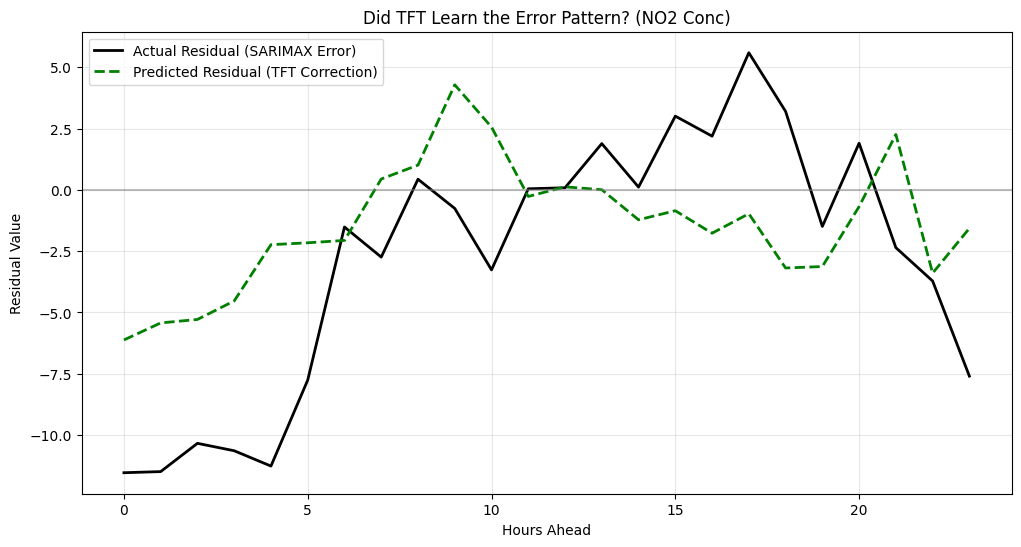

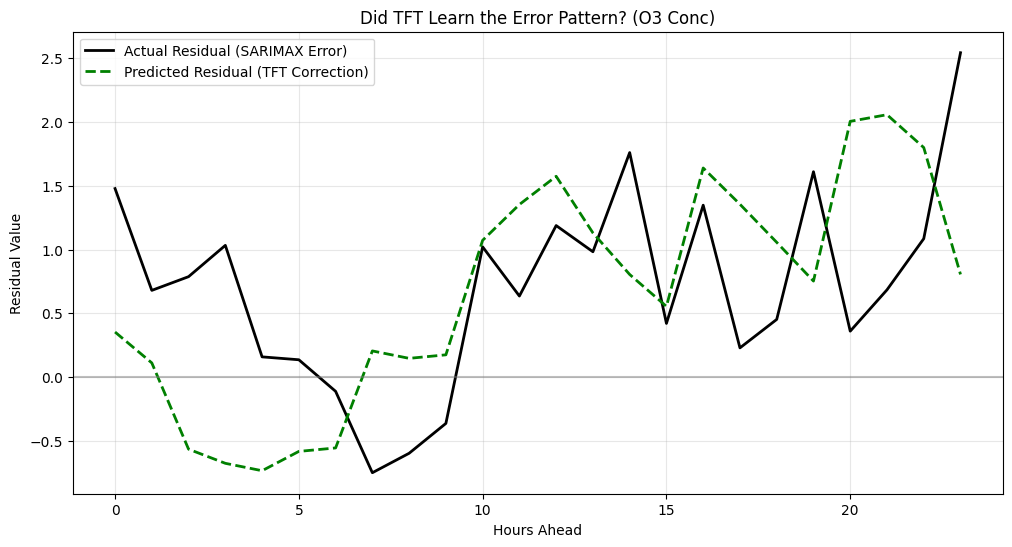

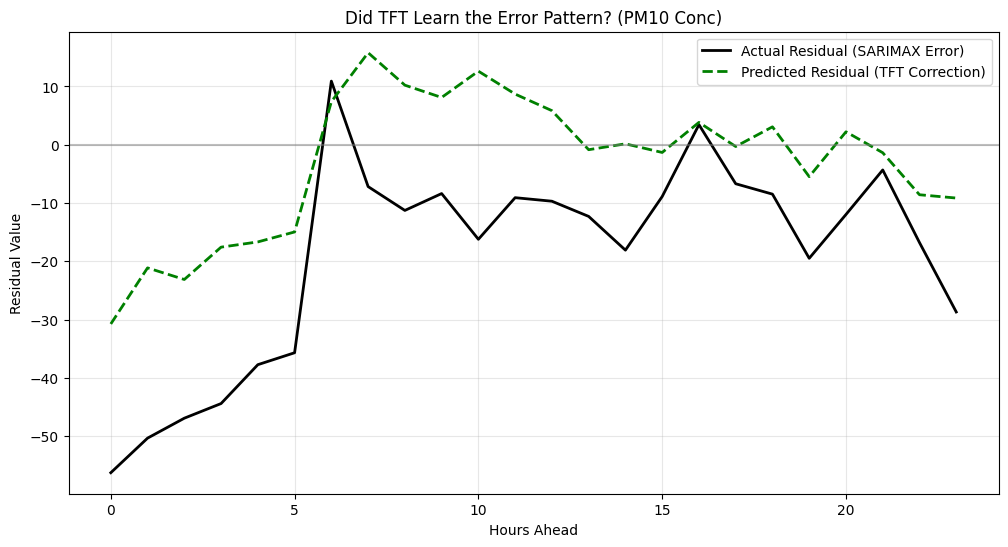

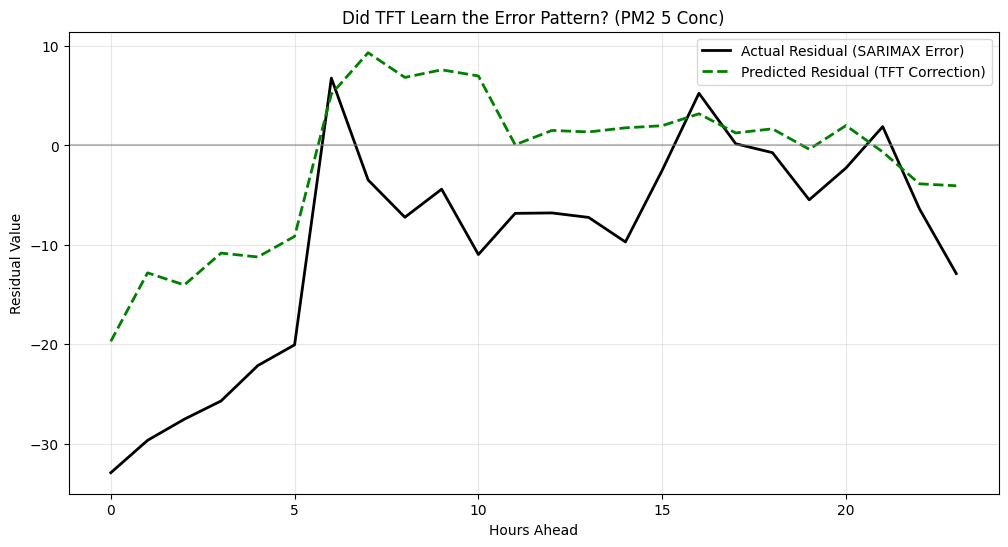

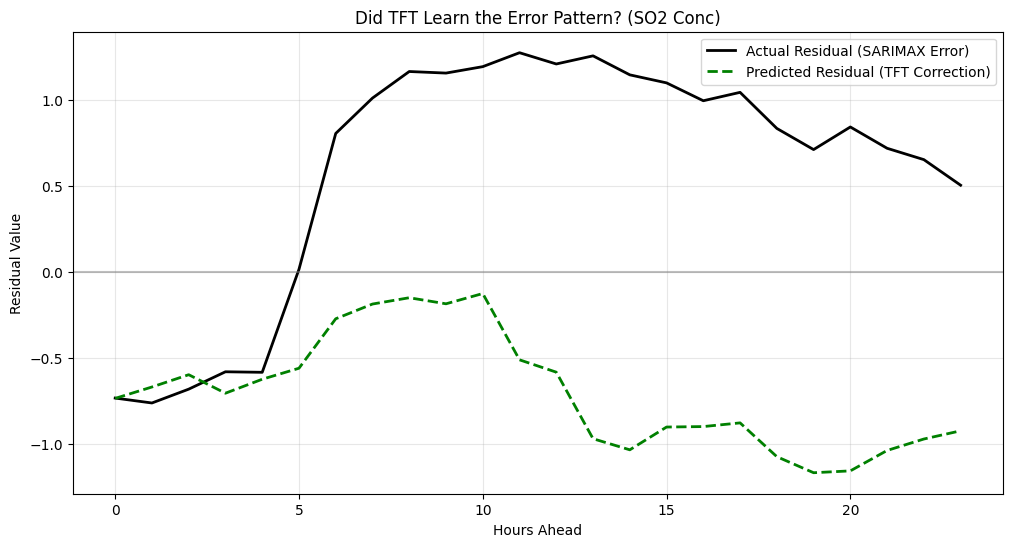

In [ ]:
groups = x['groups'].cpu().numpy().flatten()
unique_groups = np.unique(groups)

for i in range(5):
    target_g_id = unique_groups[i]
    target_name = decoder_map[target_g_id]

    # Find the first batch that belongs to this pollutant
    sample_idx = np.where(x['groups'].cpu().numpy() == target_g_id)[0][0]

    plt.figure(figsize=(12, 6))

    # Plot the 24-hour horizon
    plt.plot(actual_residuals[sample_idx], label='Actual Residual (SARIMAX Error)', color='black', linewidth=2)
    plt.plot(tft_prediction[sample_idx], label='Predicted Residual (TFT Correction)', color='green', linestyle='--', linewidth=2)

    plt.title(f"Did TFT Learn the Error Pattern? ({target_name})")
    plt.xlabel("Hours Ahead")
    plt.ylabel("Residual Value")
    plt.axhline(0, color='grey', alpha=0.5)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

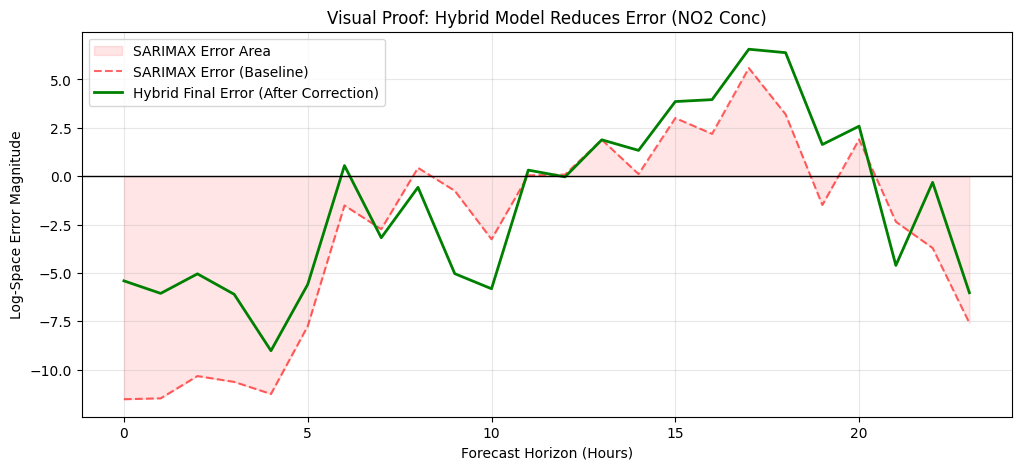

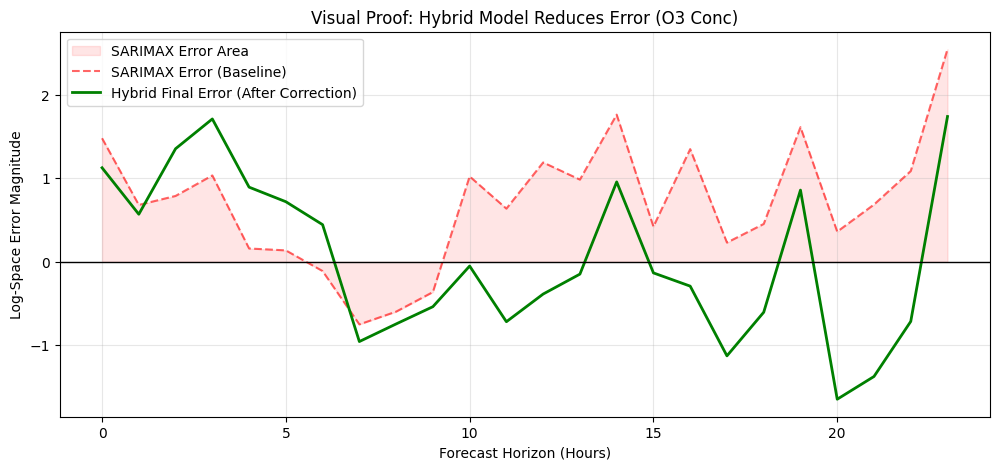

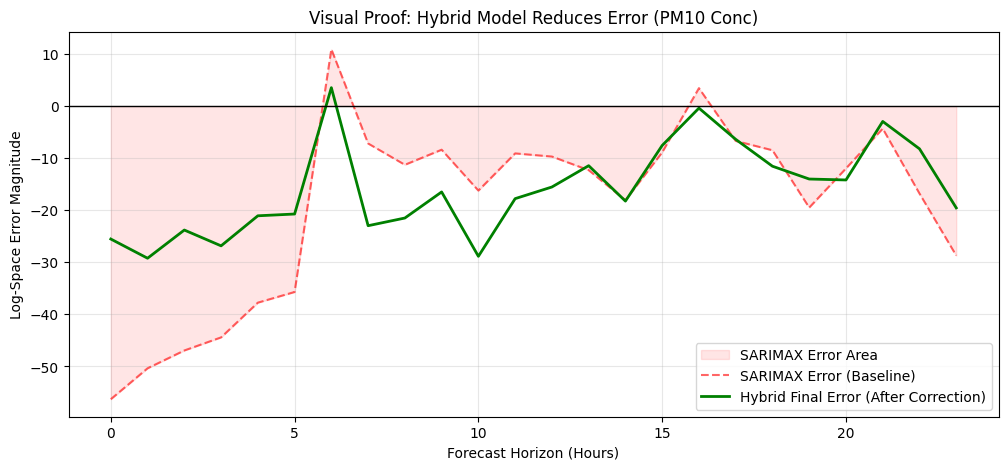

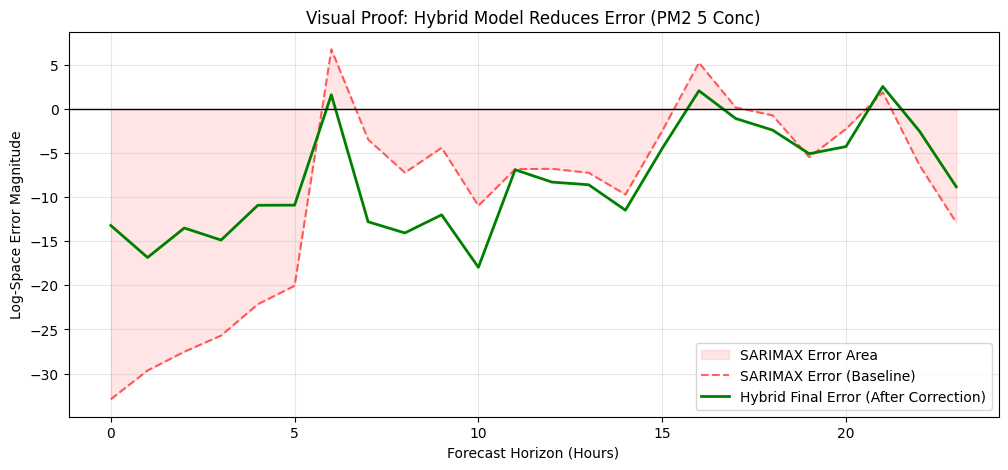

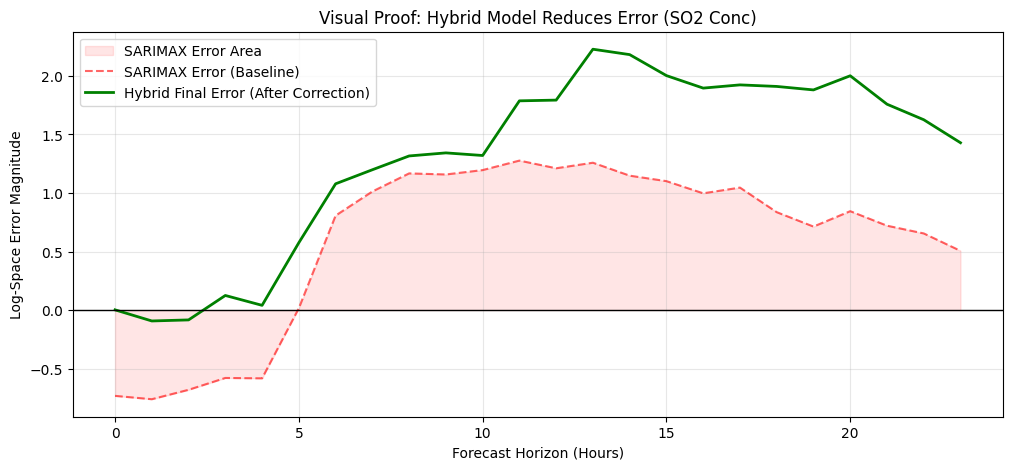

In [ ]:
for i in range(5):
    target_g_id = unique_groups[i]
    target_name = decoder_map[target_g_id]

    # Get indices for this pollutant
    sample_idx = np.where(x['groups'].cpu().numpy() == target_g_id)[0][0]

    # Get Data
    # SARIMAX Error = The raw residual
    sarimax_err = actual_residuals[sample_idx]

    # Hybrid Error
    hybrid_err = actual_residuals[sample_idx] - tft_prediction[sample_idx]

    # Plot
    plt.figure(figsize=(12, 5))

    # Plot Baseline Error
    plt.fill_between(range(len(sarimax_err)), sarimax_err, 0, color='red', alpha=0.1, label='SARIMAX Error Area')
    plt.plot(sarimax_err, color='red', linestyle='--', alpha=0.6, label='SARIMAX Error (Baseline)')

    # Plot Hybrid Error
    plt.plot(hybrid_err, color='green', linewidth=2, label='Hybrid Final Error (After Correction)')

    plt.axhline(0, color='black', linewidth=1)
    plt.title(f"Visual Proof: Hybrid Model Reduces Error ({target_name})")
    plt.xlabel("Forecast Horizon (Hours)")
    plt.ylabel("Log-Space Error Magnitude")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

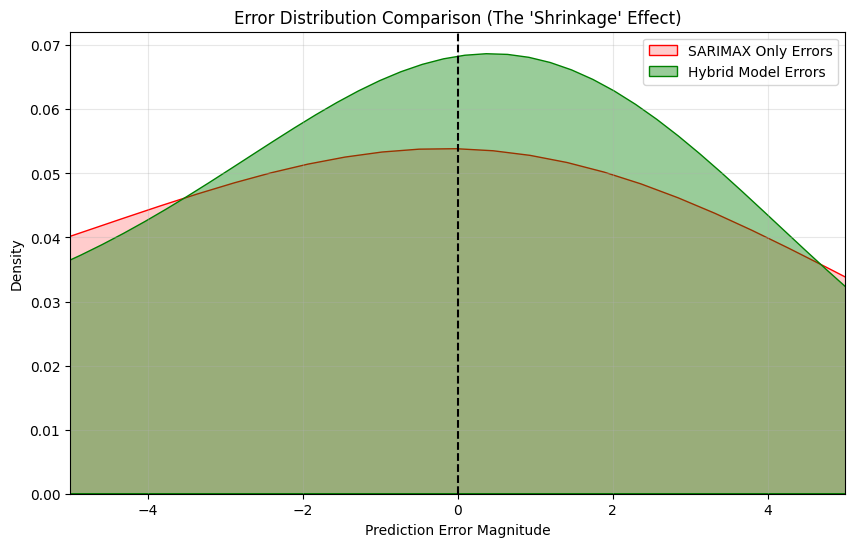

In [ ]:
# Flatten all batches to get a global view (Total Proof)
all_sarimax_err = actual_residuals.flatten()
all_hybrid_err = (actual_residuals - tft_prediction).flatten()

plt.figure(figsize=(10, 6))

# Plot SARIMAX Distribution
sns.kdeplot(all_sarimax_err, fill=True, color='red', label='SARIMAX Only Errors', alpha=0.2)

# Plot Hybrid Distribution
sns.kdeplot(all_hybrid_err, fill=True, color='green', label='Hybrid Model Errors', alpha=0.4)

plt.title("Error Distribution Comparison (The 'Shrinkage' Effect)")
plt.xlabel("Prediction Error Magnitude")
plt.ylabel("Density")
plt.xlim(-5, 5) # Adjust this limit based on your data range
plt.axvline(0, color='black', linestyle='--')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

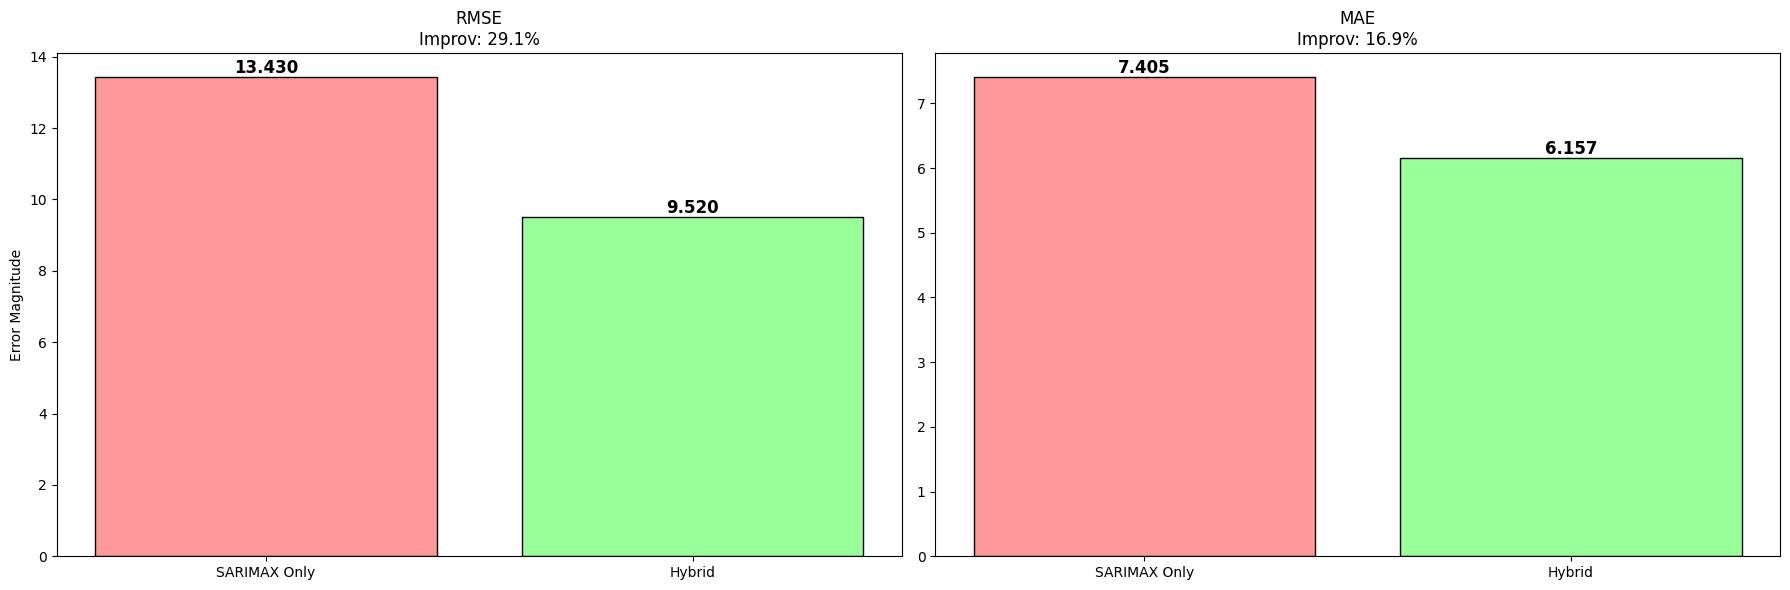

In [ ]:
# Actual Targets
y_true = actual_residuals.flatten()

# Baseline Prediction
y_pred_baseline = np.zeros_like(y_true)

# Hybrid Prediction
y_pred_hybrid = tft_prediction.flatten()

# Calculate Metrics
# RMSE
rmse_base = np.sqrt(mean_squared_error(y_true, y_pred_baseline))
rmse_hyb = np.sqrt(mean_squared_error(y_true, y_pred_hybrid))

# MAE
mae_base = mean_absolute_error(y_true, y_pred_baseline)
mae_hyb = mean_absolute_error(y_true, y_pred_hybrid)


# Plot
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
models = ['SARIMAX Only', 'Hybrid']
colors = ['#ff9999', '#99ff99']

# RMSE
bars1 = axes[0].bar(models, [rmse_base, rmse_hyb], color=colors, edgecolor='black')
axes[0].set_title(f'RMSE\nImprov: {((rmse_base-rmse_hyb)/rmse_base)*100:.1f}%')
axes[0].set_ylabel('Error Magnitude')

#  MAE
bars2 = axes[1].bar(models, [mae_base, mae_hyb], color=colors, edgecolor='black')
axes[1].set_title(f'MAE\nImprov: {((mae_base-mae_hyb)/mae_base)*100:.1f}%')

def add_labels(bars, ax):
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=12, fontweight='bold')

add_labels(bars1, axes[0])
add_labels(bars2, axes[1])

plt.tight_layout()
plt.show()

## XAI

#### SARIMAX

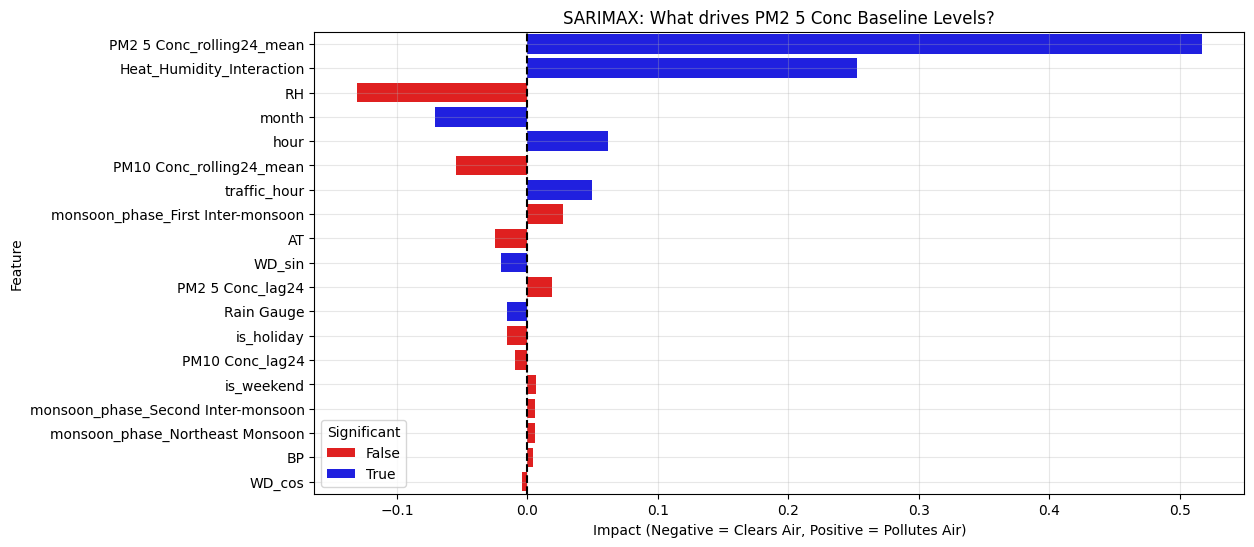

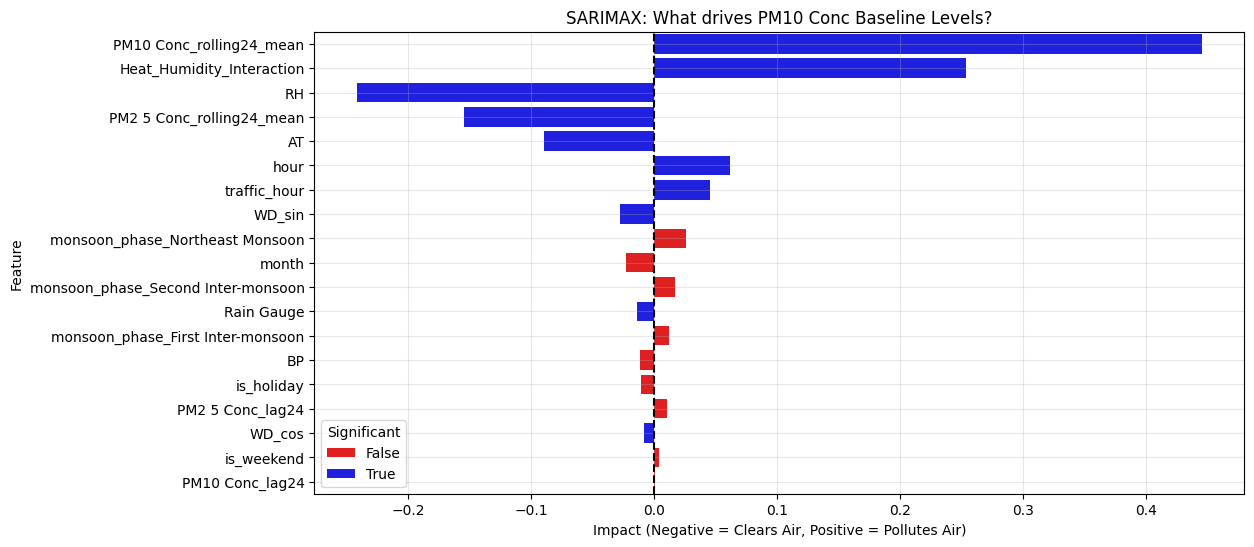

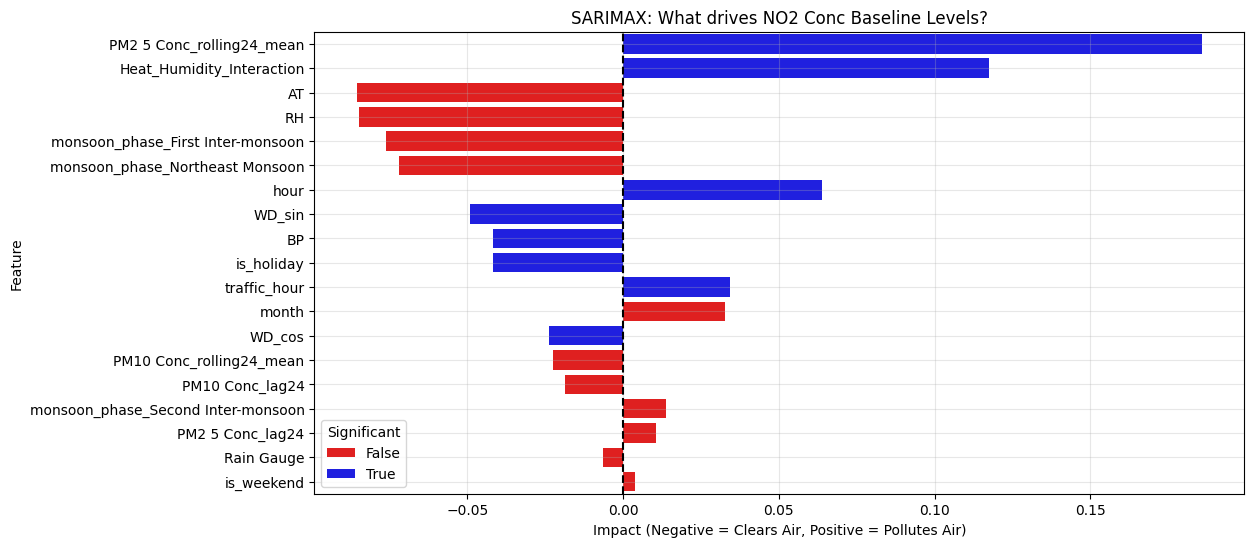

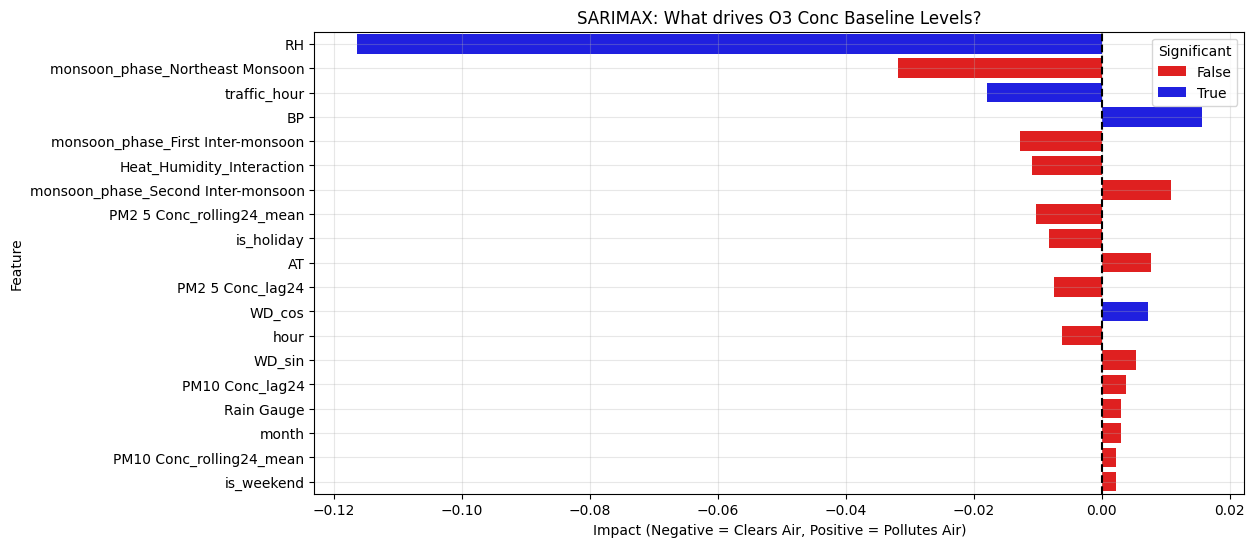

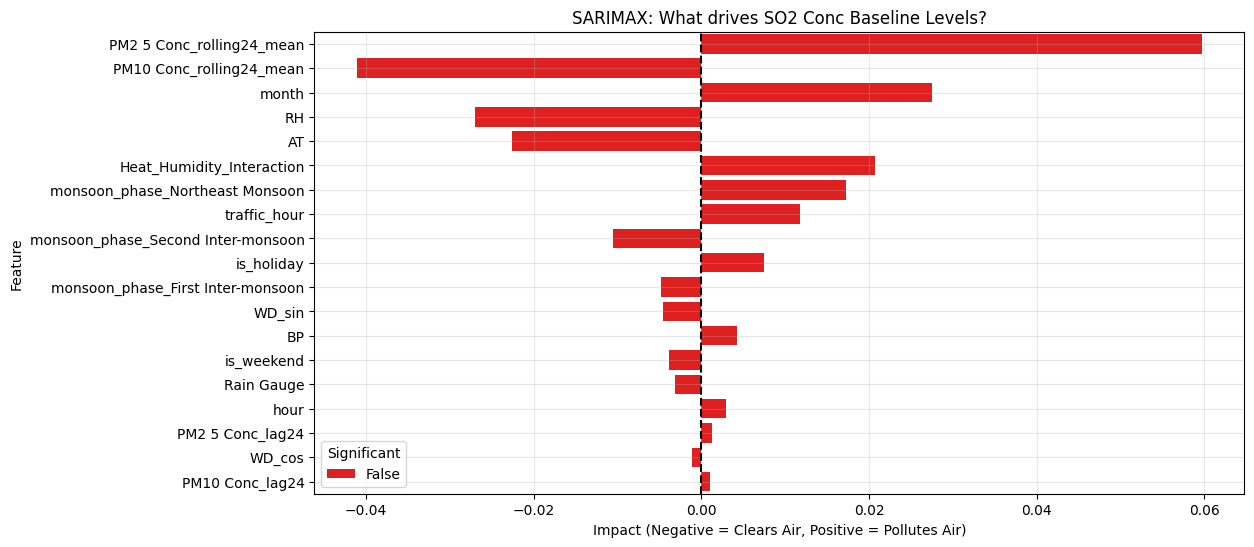

In [ ]:
pollutants = ['PM2 5 Conc', 'PM10 Conc', 'NO2 Conc', 'O3 Conc', 'SO2 Conc']

load_path = "/content/drive/MyDrive/Colab Notebooks/Research/Training /TFT + SARIMA/Kandy/Intermediates"

for poll in pollutants:

  # Load the model
  clean_poll_name = poll.replace(' ', '_')
  model_filename = f"{load_path}/kandy_sarimax_{clean_poll_name}.pkl"

  with open(model_filename, "rb") as f:
      sarimax_models = joblib.load(f)

  # Extract Coefficients & P-values
  params = sarimax_models.params
  pvalues = sarimax_models.pvalues
  feature_names = params.index

  # Filter for "Exogenous" Features only
  exog_mask = ~feature_names.str.startswith(('ar.', 'ma.', 'sigma2', 'trait_ar', 'trait_ma'))
  clean_names = feature_names[exog_mask]
  clean_params = params[exog_mask]
  clean_pvals = pvalues[exog_mask]

  # Create a DataFrame
  df_xai = pd.DataFrame({
      "Feature": clean_names,
      "Coefficient": clean_params.values,
      "P-Value": clean_pvals.values
  })

  # Add a "Significance" color
  df_xai["Significant"] = df_xai["P-Value"] < 0.05
  df_xai["Abs_Coeff"] = df_xai["Coefficient"].abs()
  df_xai = df_xai.sort_values("Abs_Coeff", ascending=False)

  # Plot
  plt.figure(figsize=(12, 6))
  sns.barplot(data=df_xai, x="Coefficient", y="Feature", hue="Significant", dodge=False, palette={True: "blue", False: "red"})
  plt.axvline(0, color="black", linestyle="--")
  plt.title(f"SARIMAX: What drives {poll} Baseline Levels?")
  plt.xlabel("Impact (Negative = Clears Air, Positive = Pollutes Air)")
  plt.grid(True, alpha=0.3)
  plt.show()

#### TFT

In [ ]:
CHECKPOINT_PATH = "/content/drive/MyDrive/Colab Notebooks/Research/Training /TFT + SARIMA/Kandy/Intermediates/Kandy_tft_model_final.ckpt"
PARAMS_PATH = "/content/drive/MyDrive/Colab Notebooks/Research/Training /TFT + SARIMA/Kandy/Intermediates/Kandy_training_dataset_params.pkl"
DATA_PATH = "/content/drive/MyDrive/Colab Notebooks/Research/Training /TFT + SARIMA/Kandy/Intermediates/kandy_tft_input_data.pkl"

In [ ]:
original_load = torch.load
torch.load = lambda f, map_location=None, weights_only=False, **kwargs: original_load(f, map_location=map_location, weights_only=False, **kwargs)

try:
    best_tft = TemporalFusionTransformer.load_from_checkpoint(f"/content/drive/MyDrive/Colab Notebooks/Research/Training /TFT + SARIMA/Kandy/Intermediates/Kandy_tft_model_final.ckpt")
    print("TFT Model loaded ")
finally:
    torch.load = original_load

best_tft.eval()
print("TFT Model loaded successfully!")

TFT Model loaded 
TFT Model loaded successfully!


In [ ]:
with open(PARAMS_PATH, "rb") as f:
    tft_params = pickle.load(f)

In [ ]:
global_tft_data = pd.read_pickle(DATA_PATH)

In [ ]:
# Create dataset
xai_dataset = TimeSeriesDataSet.from_parameters(
    tft_params,
    global_tft_data,
    predict=True,
    stop_randomization=True
)

In [ ]:
xai_loader = xai_dataset.to_dataloader(train=False, batch_size=32, num_workers=0)

INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores


<Figure size 1500x800 with 0 Axes>

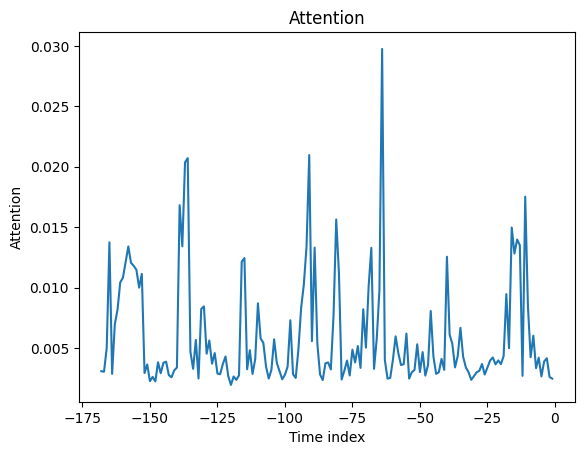

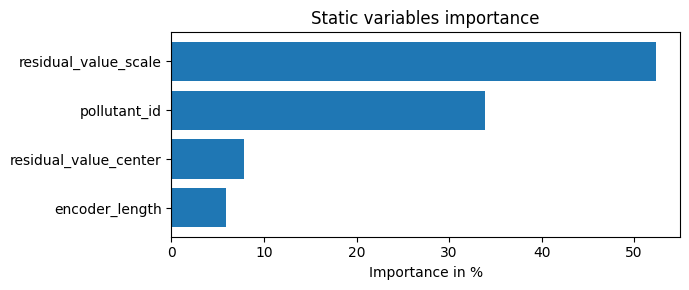

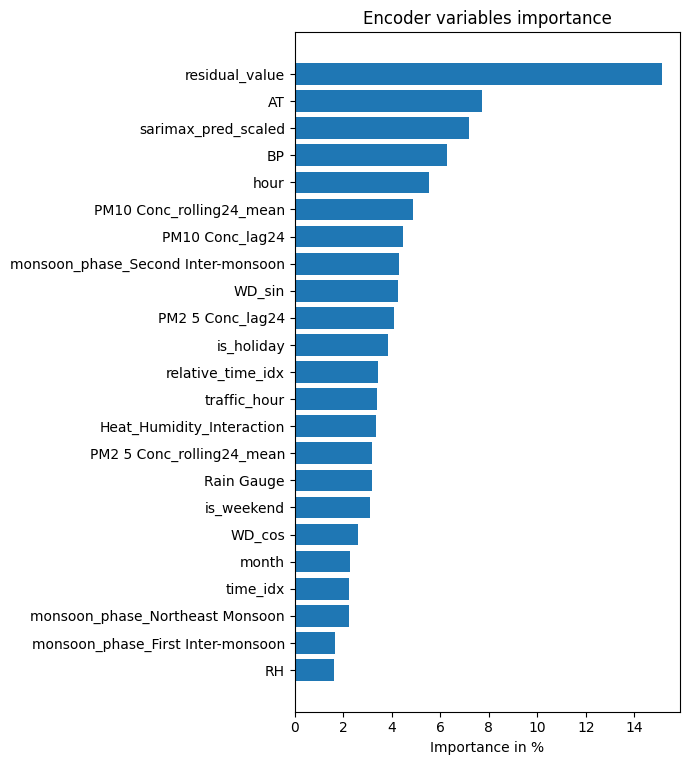

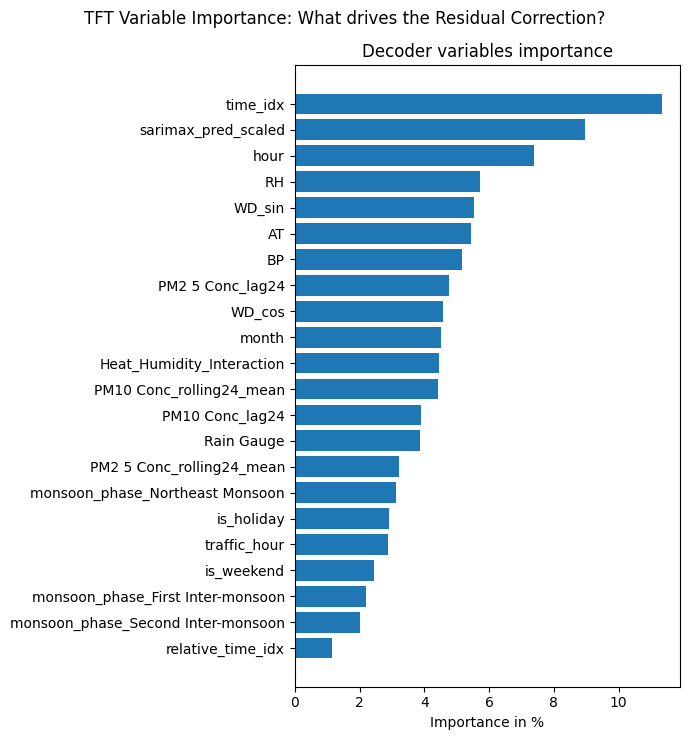

In [ ]:
# Variable Importance

# Capture ALL return values
out = best_tft.predict(xai_loader, mode="raw", return_x=True)

# Extract only the first two items (Prediction and X)
raw_prediction = out[0]
x = out[1]

# Interpret the output
interpretation = best_tft.interpret_output(raw_prediction, reduction="sum")

plt.figure(figsize=(15, 8))
best_tft.plot_interpretation(interpretation)
plt.suptitle("TFT Variable Importance: What drives the Residual Correction?")
plt.tight_layout()
plt.show()

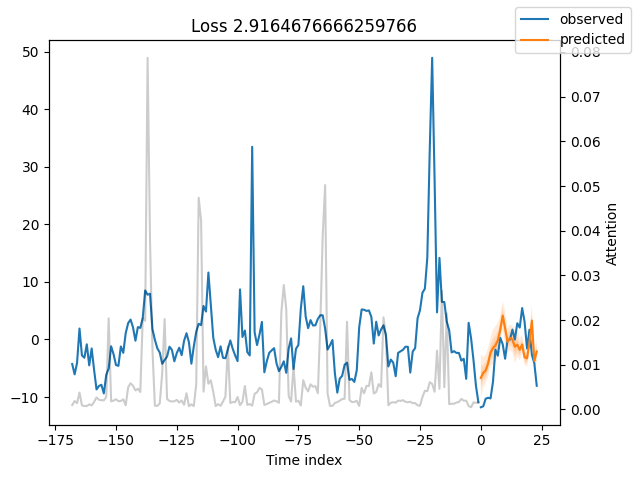

<Figure size 2000x2000 with 0 Axes>

In [ ]:
# Plot attention Mechanism
best_tft.plot_prediction(x, raw_prediction, idx=0, add_loss_to_title=True, plot_attention=True)
plt.figure(figsize=(20, 20))
plt.show()

## Generate Forecast For next 2 weeks

### Get the weather data

In [ ]:
# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after = 3600)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

In [ ]:
def get_real_weather_forecast():
    # Current Dates
    today = datetime.date.today()
    start_date = today + datetime.timedelta(days=1)
    end_date = start_date + datetime.timedelta(days=1)

    print(f"Fetching Real Weather Forecast for: {start_date} to {end_date}...")

    url = "https://api.open-meteo.com/v1/forecast"
    params = {
        "latitude": 7.2906,
        "longitude": 80.6337,
        "hourly": ["temperature_2m", "relative_humidity_2m", "rain", "surface_pressure", "wind_speed_10m", "wind_direction_10m"],
        "start_date": start_date.strftime("%Y-%m-%d"),
        "end_date": end_date.strftime("%Y-%m-%d")
    }

    # Send Request
    responses = openmeteo.weather_api(url, params=params)
    response = responses[0]

    # Process Data
    hourly = response.Hourly()

    # Extract arrays
    weather_data = {
        "Date": pd.date_range(
            start = pd.to_datetime(hourly.Time(), unit = "s", utc = True),
            end = pd.to_datetime(hourly.TimeEnd(), unit = "s", utc = True),
            freq = pd.Timedelta(seconds = hourly.Interval()),
            inclusive = "left"
        ),
        "AT": hourly.Variables(0).ValuesAsNumpy(),
        "RH": hourly.Variables(1).ValuesAsNumpy(),
        "Rain Gauge": hourly.Variables(2).ValuesAsNumpy(),
        "BP": hourly.Variables(3).ValuesAsNumpy(),
        "wind_speed": hourly.Variables(4).ValuesAsNumpy(),
        "wind_deg": hourly.Variables(5).ValuesAsNumpy()
    }

    weather_df = pd.DataFrame(data=weather_data)

    # Feature Engineering
    # Wind
    wd_rad = weather_df['wind_deg'] * np.pi / 180
    weather_df['WD_sin'] = np.sin(wd_rad)
    weather_df['WD_cos'] = np.cos(wd_rad)

    # Time
    weather_df['hour'] = weather_df['Date'].dt.hour
    weather_df['month'] = weather_df['Date'].dt.month
    weather_df['day_of_week'] = weather_df['Date'].dt.dayofweek
    weather_df['is_weekend'] = weather_df['day_of_week'].isin([5, 6]).astype(int)
    weather_df['traffic_hour'] = (
        weather_df['hour'].isin(range(7, 10)) |
        weather_df['hour'].isin(range(17, 20))
    ).astype(int)

    # Holiday
    sl_holidays = holidays.SriLanka(years=[2025, 2026])

    # Check if the Forecast Date is in the holiday list
    weather_df['is_holiday'] = weather_df['Date'].dt.date.isin(sl_holidays).astype(int)

    # Monsoon (Dec/Jan is Northeast)
    weather_df['monsoon_phase_Northeast Monsoon'] = weather_df['month'].isin([12, 1, 2]).astype(int)
    weather_df['monsoon_phase_First Inter-monsoon'] = weather_df['month'].isin([3, 4]).astype(int)
    weather_df['monsoon_phase_Southwest Monsoon'] = weather_df['month'].isin([5, 6, 7, 8, 9]).astype(int)
    weather_df['monsoon_phase_Second Inter-monsoon'] = weather_df['month'].isin([10, 11]).astype(int)

    # Interaction
    weather_df['Heat_Humidity_Interaction'] = weather_df['AT'] * weather_df['RH']

    return weather_df.iloc[:forecast_horizon]

### Forecasting

In [ ]:
forecast_horizon = 24

In [ ]:
load_path = "/content/drive/MyDrive/Colab Notebooks/Research/Training /TFT + SARIMA/Kandy/Intermediates"

In [ ]:
global_tft_data = pd.read_pickle("/content/drive/MyDrive/Colab Notebooks/Research/Training /TFT + SARIMA/Kandy/Intermediates/kandy_tft_input_data.pkl")

In [ ]:
tft_params = pd.read_pickle("/content/drive/MyDrive/Colab Notebooks/Research/Training /TFT + SARIMA/Kandy/Intermediates/Kandy_training_dataset_params.pkl")

In [ ]:
pollutants = ['PM2 5 Conc', 'PM10 Conc', 'NO2 Conc', 'O3 Conc', 'SO2 Conc']

### Features for SARIMAX

In [ ]:
sarimax_features = [
    'PM2 5 Conc_lag24', 'PM2 5 Conc_rolling24_mean',
    'PM10 Conc_lag24', 'PM10 Conc_rolling24_mean',
    'AT', 'RH', 'BP', 'Rain Gauge', 'WD_sin', 'WD_cos',
    'monsoon_phase_First Inter-monsoon', 'monsoon_phase_Northeast Monsoon',
    'monsoon_phase_Second Inter-monsoon',
    'traffic_hour', 'is_weekend', 'is_holiday',
    'month', 'hour', 'Heat_Humidity_Interaction'
]

### Get the real Weather

In [ ]:
real_future_weather = get_real_weather_forecast()

Fetching Real Weather Forecast for: 2025-12-31 to 2026-01-01...


### Sync with existing data

In [ ]:
last_global_idx = global_tft_data['time_idx'].max()
future_time_idxs = range(last_global_idx + 1, last_global_idx + 1 + len(real_future_weather))
real_future_weather['time_idx'] = list(future_time_idxs)

In [ ]:
final_results = pd.DataFrame(index=range(forecast_horizon))

#### Load TFT Model

In [ ]:
original_load = torch.load
torch.load = lambda f, map_location=None, weights_only=False, **kwargs: original_load(f, map_location=map_location, weights_only=False, **kwargs)

try:
    tft = TemporalFusionTransformer.load_from_checkpoint(f"{load_path}/Kandy_tft_model_final.ckpt")
    print("TFT Model loaded ")
finally:
    torch.load = original_load

tft.eval()
print("TFT Model loaded successfully!")

TFT Model loaded 
TFT Model loaded successfully!


### Forecast Loop

In [ ]:
for poll in pollutants:
    print(f"\nProcessing: {poll}...")

    # Prepare Data
    # Get History (Last 168 hours)
    poll_history = global_tft_data[global_tft_data['pollutant_id'] == poll].tail(168).copy()

    # Get Future
    poll_future = real_future_weather.copy()
    poll_future['pollutant_id'] = poll

    # Fill Lags (Forward Fill Last Known History)
    last_val = poll_history['residual_value'].iloc[-1]

    # Safely get last known lags
    last_pm25 = poll_history['PM2 5 Conc_lag24'].iloc[-1] if 'PM2 5 Conc_lag24' in poll_history else 0
    last_no2 = poll_history['NO2 Conc_lag24'].iloc[-1] if 'NO2 Conc_lag24' in poll_history else 0

    # Apply to Future
    poll_future['PM2 5 Conc_lag24'] = last_pm25
    poll_future['PM2 5 Conc_rolling24_mean'] = last_pm25
    poll_future['PM10 Conc_lag24'] = last_pm25 * 1.5
    poll_future['PM10 Conc_rolling24_mean'] = last_pm25 * 1.5
    poll_future['NO2 Conc_lag24'] = last_no2

    # Combine
    temp_inf_df = pd.concat([poll_history, poll_future], ignore_index=True)

    temp_inf_df['residual_value'] = temp_inf_df['residual_value'].fillna(0.0)

    # Ensure SARIMAX column is clean
    temp_inf_df['sarimax_pred_scaled'] = temp_inf_df['sarimax_pred_scaled'].fillna(0.0)

    # SARIMAX Prediction
    clean_poll_name = poll.replace(' ', '_')
    model_filename = f"{load_path}/kandy_sarimax_{clean_poll_name}.pkl"
    scaler_filename = f"{load_path}/kandy_scaler_{clean_poll_name}.pkl"

    try:
        with open(model_filename, "rb") as f:
            sarimax_model = joblib.load(f)

        with open(scaler_filename, "rb") as f:
            scaler = joblib.load(f)

        # Prepare Exog & scale
        future_exog_raw = temp_inf_df.iloc[-forecast_horizon:][sarimax_features].fillna(0)

        # Transform
        exog_array = scaler.transform(future_exog_raw)

        # Predict
        start_idx = int(sarimax_model.nobs)
        end_idx = start_idx + forecast_horizon - 1

        pred_obj = sarimax_model.predict(
            start=start_idx,
            end=end_idx,
            exog=exog_array,
            dynamic=False
        )

        if hasattr(pred_obj, 'values'):
            log_pred = pred_obj.values
        else:
            log_pred = pred_obj

        # Inverse Log & Clip
        base_pred = np.expm1(log_pred)
        base_pred = np.maximum(base_pred, 0.0)

    except Exception as e:
        print(f" SARIMAX Error: {e}")
        base_pred = np.full(forecast_horizon, last_val)

    # Update TFT inputs
    p_mean = base_pred.mean()
    p_std = base_pred.std() + 1e-6
    scaled_pred = (base_pred - p_mean) / p_std

    # Assign prediction to future rows
    target_idx_start = len(temp_inf_df) - forecast_horizon
    col_idx = temp_inf_df.columns.get_loc('sarimax_pred_scaled')

    pred_vals = scaled_pred.values if hasattr(scaled_pred, 'values') else scaled_pred

    # Force Length Match
    if len(pred_vals) > forecast_horizon:
        pred_vals = pred_vals[:forecast_horizon]
    elif len(pred_vals) < forecast_horizon:
        pred_vals = np.concatenate([pred_vals, np.full(forecast_horizon - len(pred_vals), pred_vals[-1])])

    temp_inf_df.iloc[target_idx_start:, col_idx] = pred_vals

    # TFT prediction
    inf_ds = TimeSeriesDataSet.from_parameters(
        tft_params,
        temp_inf_df,
        predict=True,
        stop_randomization=True
        )

    inf_loader = inf_ds.to_dataloader(train=False, batch_size=1, num_workers=0)

    tft_prediction = tft.predict(inf_loader, mode="prediction").numpy().flatten()

    # Combine models
    min_len = min(len(base_pred), len(tft_prediction))

    # Calculate Hybrid
    hybrid_val = base_pred[:min_len] + tft_prediction[:min_len]

    # Fallback in case of negative predictions
    final_val = np.where(hybrid_val < 0, base_pred[:min_len], hybrid_val)

    # Safety Clip
    final_val = np.maximum(final_val, 0.0)

    # Pad if needed
    if len(final_val) < forecast_horizon:
        final_val = np.concatenate([final_val, np.full(forecast_horizon - len(final_val), final_val[-1])])

    # Save
    final_results[poll] = final_val


Processing: PM2 5 Conc...


INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores



Processing: PM10 Conc...


INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores



Processing: NO2 Conc...


INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores



Processing: O3 Conc...


INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores



Processing: SO2 Conc...


INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO: GPU available: False, used: False
INFO:lightning.pytorch.utilities.rank_zero:GPU available: False, used: False
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores


In [ ]:
print(final_results.head())

   PM2 5 Conc  PM10 Conc  NO2 Conc   O3 Conc  SO2 Conc
0    8.806856   9.382354  2.707351  6.462578  1.838680
1    8.784085  12.852079  4.221556  5.810730  2.155040
2    7.021470   9.195268  4.429583  5.210819  1.791365
3   11.011757  20.041267  4.140390  5.153936  1.001528
4    2.313081   3.862896  2.305679  4.336930  0.739055


In [ ]:
final_results['Date_Time'] = real_future_weather['Date'].iloc[:len(final_results)].values

In [ ]:
cols = ['Date_Time'] + [c for c in final_results.columns if c != 'Date_Time']
final_results = final_results[cols]

In [ ]:
final_results

,Date_Time,PM2 5 Conc,PM10 Conc,NO2 Conc,O3 Conc,SO2 Conc
0,2025-12-31 00:00:00,8.806856,9.382354,2.707351,6.462578,1.838680
1,2025-12-31 01:00:00,8.784085,12.852079,4.221556,5.810730,2.155040
2,2025-12-31 02:00:00,7.021470,9.195268,4.429583,5.210819,1.791365
3,2025-12-31 03:00:00,11.011757,20.041267,4.140390,5.153936,1.001528
4,2025-12-31 04:00:00,2.313081,3.862896,2.305679,4.336930,0.739055
5,2025-12-31 05:00:00,6.452980,1.782690,4.685492,3.540694,0.659903
6,2025-12-31 06:00:00,11.038185,25.045818,4.629666,1.465089,0.620749
7,2025-12-31 07:00:00,7.007433,16.098980,2.017222,1.470242,0.454976
8,2025-12-31 08:00:00,2.758288,24.331466,6.626358,1.421747,0.553981
9,2025-12-31 09:00:00,11.709562,21.350031,8.677227,4.369677,0.654737


# XGboost + TFT

## Train XGBoost for all

### Features

In [ ]:
TARGETS = ['PM2 5 Conc', 'PM10 Conc', 'SO2 Conc', 'NO2 Conc', 'O3 Conc', 'CO Conc']

In [ ]:
xgb_features = [
    'AT', 'RH', 'BP', 'Solar Rad', 'Rain Gauge',
    'hour', 'day_of_week', 'month', 'day_of_year',
    'is_weekend', 'is_holiday', 'traffic_hour', 'is_covid_lockdown',
    'sin_hour', 'cos_hour', 'sin_day_of_year', 'cos_day_of_year',
    'WD_sin', 'WD_cos', 'Heat_Humidity_Interaction', 'Traffic_Stagnation', 'Low_Activity_Zone',
    'monsoon_phase_First Inter-monsoon', 'monsoon_phase_Northeast Monsoon',
    'monsoon_phase_Second Inter-monsoon', 'monsoon_phase_Southwest Monsoon',
    'PM2 5 Conc_lag24', 'PM2 5 Conc_rolling24_mean', 'PM2 5 Conc_rolling24_std',
    'PM10 Conc_lag24', 'PM10 Conc_rolling24_mean', 'PM10 Conc_rolling24_std',
    'NO2 Conc_lag24', 'NO2 Conc_rolling24_mean', 'NO2 Conc_rolling24_std',
    'AT_rolling72_mean', 'RH_rolling72_mean', 'Solar Rad_rolling72_mean'
]

### Data for the model

In [ ]:
df_xgb = df.copy()

In [ ]:
bool_cols = ['is_weekend', 'is_holiday', 'is_covid_lockdown', 'Low_Activity_Zone']
for col in bool_cols:
    if col in df_xgb.columns:
        df_xgb[col] = df_xgb[col].astype(str).map({'True': 1, 'False': 0, '1': 1, '0': 0, '1.0': 1, '0.0': 0}).fillna(0).astype(int)

### Train Model & Predict for generating Residuals

In [ ]:
xgb_models = {}

In [ ]:
for target in TARGETS:
    print(target)

    split_idx = int(len(df_xgb) * 0.8)
    X = df_xgb[xgb_features]
    y = df_xgb[target]

    X_train, y_train = X.iloc[:split_idx], y.iloc[:split_idx]

    model = xgb.XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        n_jobs=-1,
        objective='reg:squarederror'
    )
    model.fit(X_train, y_train, verbose=False)
    xgb_models[target] = model

    # Predict
    all_preds = model.predict(X)

    # Save Predictions & Residuals to the main DataFrame
    safe_target_name = target.replace('.', ' ')

    df_xgb[f"XGB_Pred_{safe_target_name}"] = all_preds
    df_xgb[f"{safe_target_name}_residual"] = df_xgb[target] - all_preds

PM2 5 Conc
PM10 Conc
SO2 Conc
NO2 Conc
O3 Conc
CO Conc


### Clean the data for TFT model

In [ ]:
df_clean = df_xgb.replace([np.inf, -np.inf], np.nan).copy()

In [ ]:
resid_cols = [c for c in df_clean.columns if c.endswith("_residual")]
xgb_pred_cols = [c for c in df_clean.columns if c.startswith("XGB_Pred_")]

In [ ]:
initial_len = len(df_clean)
df_clean = df_clean.dropna(subset=resid_cols + xgb_pred_cols).reset_index(drop=True)

In [ ]:
dropped_count = initial_len - len(df_clean)

In [ ]:
df_clean['group_id'] = 'location_1'
df_clean['time_idx'] = np.arange(len(df_clean))

In [ ]:
cat_cols_for_tft = [
    'is_weekend', 'is_holiday', 'is_covid_lockdown',
    'traffic_hour',
    'monsoon_phase_First Inter-monsoon', 'monsoon_phase_Northeast Monsoon',
    'monsoon_phase_Second Inter-monsoon', 'monsoon_phase_Southwest Monsoon'
]

In [ ]:
for col in cat_cols_for_tft:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].astype(int).astype(str).astype("category")

In [ ]:
df_xgb = df_clean.copy()

## Train TFT Model

### Convert caregorical columnn to Strings

In [ ]:
cat_cols_to_fix = [
    'is_weekend', 'is_holiday', 'is_covid_lockdown',
    'traffic_hour',
    'monsoon_phase_First Inter-monsoon', 'monsoon_phase_Northeast Monsoon',
    'monsoon_phase_Second Inter-monsoon', 'monsoon_phase_Southwest Monsoon'
]

In [ ]:
for col in cat_cols_to_fix:
    if col in df_xgb.columns:
        # Convert to Int -> String -> Category
        df_xgb[col] = df_xgb[col].astype(float).astype(int).astype(str).astype("category")

### Get the columns

In [ ]:
cat_cols_to_fix = [
    'is_weekend', 'is_holiday', 'is_covid_lockdown',
    'traffic_hour',
    'monsoon_phase_First Inter-monsoon', 'monsoon_phase_Northeast Monsoon',
    'monsoon_phase_Second Inter-monsoon', 'monsoon_phase_Southwest Monsoon'
]

In [ ]:
for col in cat_cols_to_fix:
    if col in df_xgb.columns:
        # Convert to Int -> String -> Category
        df_xgb[col] = df_xgb[col].astype(float).astype(int).astype(str).astype("category")

In [ ]:
XGB_PRED_COLS = [c for c in df_xgb.columns if c.startswith("XGB_Pred_")]
TARGETS_RESIDUALS = [c for c in df_xgb.columns if c.endswith("_residual")]

### Define Dataset

In [ ]:
max_encoder_length = 168
training_cutoff = df_xgb["time_idx"].max() - (24 * 7)

In [ ]:
training = TimeSeriesDataSet(
    df_xgb[lambda x: x.time_idx <= training_cutoff],
    time_idx="time_idx",
    target=TARGETS_RESIDUALS,
    group_ids=["group_id"],

    min_encoder_length=max_encoder_length // 2,
    max_encoder_length=max_encoder_length,
    min_prediction_length=1,
    max_prediction_length=24,

    static_categoricals=[],
    static_reals=[],

    time_varying_known_categoricals=cat_cols_to_fix,

    time_varying_known_reals=[
        'time_idx', 'hour', 'day_of_week', 'month',
        'sin_hour', 'cos_hour', 'sin_day_of_year', 'cos_day_of_year',
    ] + XGB_PRED_COLS,

    time_varying_unknown_reals=[
        'AT', 'RH', 'BP', 'Solar Rad', 'Rain Gauge',
        'WD_sin', 'WD_cos', 'Heat_Humidity_Interaction'
    ] + TARGETS_RESIDUALS,

    target_normalizer=MultiNormalizer([
        GroupNormalizer(groups=["group_id"], transformation=None)
        for _ in TARGETS_RESIDUALS
    ]),

    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
)

In [ ]:
validation = TimeSeriesDataSet.from_dataset(training, df_xgb, predict=True, stop_randomization=True)
train_dataloader = training.to_dataloader(train=True, batch_size=256, num_workers=2)
val_dataloader = validation.to_dataloader(train=False, batch_size=256, num_workers=2)

### Model Train

In [ ]:
checkpoint_callback = ModelCheckpoint(
    monitor="val_loss", mode="min", save_top_k=1, filename="tft_residual_best"
)

In [ ]:
early_stop_callback = EarlyStopping(
    monitor="val_loss", min_delta=1e-4, patience=15, verbose=True, mode="min"
)

In [ ]:
lr_logger = LearningRateMonitor()

In [ ]:
trainer = pl.Trainer(
    max_epochs=30,
    accelerator="gpu",
    devices=1,
    gradient_clip_val=0.1,
    callbacks=[lr_logger, early_stop_callback, checkpoint_callback],
    enable_progress_bar=True,
    enable_model_summary=True,
)

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores


In [ ]:
tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=0.005,
    hidden_size=128,
    attention_head_size=8,
    dropout=0.,
    hidden_continuous_size=32,
    loss=QuantileLoss(),
)

In [ ]:
 trainer.fit(tft, train_dataloaders=train_dataloader, val_dataloaders=val_dataloader)

INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ MultiLoss                       │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │     16 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │  2.7 K │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │  152 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │  373 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │  187 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │ 66.3 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │ 66.3 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │ 66.3 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │ 66.3 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  132 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  132 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │ 33.0 K │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │    256 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │ 82.7 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │ 37.1 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │ 33.3 K │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │ 66.3 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │ 33.3 K │ train │     0 │
│ 20 │ output_layer                       │ ModuleList                      │  5.4 K │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 1.5 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 1.5 M                                                                                                
Total estimated model params size (MB): 6                                                                          
Modules in train mode: 1087                                                                                        
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

INFO: Metric val_loss improved. New best score: 1831.860
INFO:lightning.pytorch.callbacks.early_stopping:Metric val_loss improved. New best score: 1831.860
INFO: Metric val_loss improved by 91.295 >= min_delta = 0.0001. New best score: 1740.565
INFO:lightning.pytorch.callbacks.early_stopping:Metric val_loss improved by 91.295 >= min_delta = 0.0001. New best score: 1740.565
INFO: Monitored metric val_loss did not improve in the last 15 records. Best score: 1740.565. Signaling Trainer to stop.
INFO:lightning.pytorch.callbacks.early_stopping:Monitored metric val_loss did not improve in the last 15 records. Best score: 1740.565. Signaling Trainer to stop.


## Evaluations

### Testing Length

In [ ]:
TEST_DAYS = 7
TEST_HOURS = TEST_DAYS * 24

### Features

In [ ]:
xgb_features = [
    'AT', 'RH', 'BP', 'Solar Rad', 'Rain Gauge',
    'hour', 'day_of_week', 'month', 'day_of_year',
    'is_weekend', 'is_holiday', 'traffic_hour', 'is_covid_lockdown',
    'sin_hour', 'cos_hour', 'sin_day_of_year', 'cos_day_of_year',
    'WD_sin', 'WD_cos', 'Heat_Humidity_Interaction',
    'Traffic_Stagnation', 'Low_Activity_Zone',
    'monsoon_phase_First Inter-monsoon', 'monsoon_phase_Northeast Monsoon',
    'monsoon_phase_Second Inter-monsoon', 'monsoon_phase_Southwest Monsoon',
    'PM2 5 Conc_lag24', 'PM2 5 Conc_rolling24_mean', 'PM2 5 Conc_rolling24_std',
    'PM10 Conc_lag24', 'PM10 Conc_rolling24_mean', 'PM10 Conc_rolling24_std',
    'NO2 Conc_lag24', 'NO2 Conc_rolling24_mean', 'NO2 Conc_rolling24_std',
    'AT_rolling72_mean', 'RH_rolling72_mean', 'Solar Rad_rolling72_mean'
]

### Get Data and get Prediction

In [ ]:
# Define Test Slice
encoder_len = training.max_encoder_length

In [ ]:
cutoff_test = df_xgb['time_idx'].max() - TEST_HOURS - encoder_len

In [ ]:
test_df = df_xgb[lambda x: x.time_idx > cutoff_test].copy()

In [ ]:
test_df_numeric = test_df.copy()

In [ ]:
# Force Categoricals back to Numeric for XGBoost Inference
# (XGBoost needs 0/1, but test_df currently has "0"/"1" strings for TFT)
for col in ['is_weekend', 'is_holiday', 'is_covid_lockdown', 'Low_Activity_Zone']:
    if col in test_df_numeric.columns:
        test_df_numeric[col] = test_df_numeric[col].astype(str).astype(float).astype(int)

### Predict

In [ ]:
for target in TARGETS:
    # Predict using the numeric view
    preds = xgb_models[target].predict(test_df_numeric[xgb_features])

    # Store in the MAIN test_df (as feature for TFT)
    # Note: We use the space-replaced name because that's what TFT expects
    safe_name = f"XGB_Pred_{target.replace('.', ' ')}"
    test_df[safe_name] = preds

### TFT Predictions

In [ ]:
test_dataset = TimeSeriesDataSet.from_dataset(
    training,
    test_df,
    predict=True,
    stop_randomization=True
)
test_dataloader = test_dataset.to_dataloader(train=False, batch_size=256, num_workers=2)

In [ ]:
raw_predictions, x, index, *ignored = tft.predict(
    test_dataloader,
    mode="raw",
    return_x=True,
    return_index=True
)

INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


In [ ]:
tft_residual_preds = torch.stack([p[..., 3] for p in raw_predictions['prediction']], dim=-1).cpu().numpy()

In [ ]:
pred_time_indices = index['time_idx'].values

### Combine and Evaluate

In [ ]:
metrics_list = []

In [ ]:
# Get the maximum index we actually have data for
max_available_idx = test_df['time_idx'].max()

In [ ]:
for i, target_resid in enumerate(TARGETS_RESIDUALS):
    real_target_name = TARGETS[i]
    safe_col_name = target_resid.replace("_residual", "")

    # Get flattened predictions and time indices
    pred_residuals = tft_residual_preds[:, :, i].flatten()

    flat_time_idxs = []
    for start_idx in pred_time_indices:
        flat_time_idxs.append(np.arange(start_idx + 1, start_idx + 1 + 24))
    flat_time_idxs = np.concatenate(flat_time_idxs)

    # We only keep predictions where we actually have the Ground Truth data
    valid_mask = flat_time_idxs <= max_available_idx

    # Apply mask to both indices and predictions
    flat_time_idxs = flat_time_idxs[valid_mask]
    pred_residuals = pred_residuals[valid_mask]

    # Check if we have any data left to evaluate
    if len(flat_time_idxs) == 0:
        print(f"No valid evaluation data for {real_target_name} (All predictions are future)")
        continue

    # Pull Aligned Data
    aligned_df = test_df.set_index('time_idx').loc[flat_time_idxs]

    # Actual Values
    if real_target_name in aligned_df.columns:
        y_true = aligned_df[real_target_name].values
    else:
        y_true = aligned_df[safe_col_name].values

    # Base Values (XGBoost)
    y_base = aligned_df[f"XGB_Pred_{safe_col_name}"].values

    # Hybrid Values
    y_hybrid = y_base + pred_residuals

    # --- METRICS ---
    rmse_base = np.sqrt(mean_squared_error(y_true, y_base))
    rmse_hybrid = np.sqrt(mean_squared_error(y_true, y_hybrid))

    mae_base = mean_absolute_error(y_true, y_base)
    mae_hybrid = mean_absolute_error(y_true, y_hybrid)

    if np.var(y_true) < 1e-6:
        r2_val = 0.0
    else:
        r2_val = r2_score(y_true, y_hybrid)

    imp_rmse = ((rmse_base - rmse_hybrid) / rmse_base) * 100 if rmse_base > 0 else 0.0
    imp_mae = ((mae_base - mae_hybrid) / mae_base) * 100 if mae_base > 0 else 0.0

    metrics_list.append({
        "Pollutant": real_target_name,
        "Base RMSE": round(rmse_base, 2),
        "Hybrid RMSE": round(rmse_hybrid, 2),
        "RMSE Imp": f"{imp_rmse:.1f}%",
        "Base MAE": round(mae_base, 2),
        "Hybrid MAE": round(mae_hybrid, 2),
        "MAE Imp": f"{imp_mae:.1f}%",
        "Hybrid R2": f"{r2_val:.3f}"
    })

In [ ]:
if len(metrics_list) > 0:
    scorecard_df = pd.DataFrame(metrics_list).set_index("Pollutant")
    print("Hybrid Model Scorecard (XGBoost + TFT):")
    print(scorecard_df.sort_values("RMSE Imp", ascending=False).to_string())
else:
    print("Report is empty.")

Hybrid Model Scorecard (XGBoost + TFT):
            Base RMSE  Hybrid RMSE RMSE Imp  Base MAE  Hybrid MAE MAE Imp Hybrid R2
Pollutant                                                                          
O3 Conc          9.16         3.46    62.2%      8.54        2.99   64.9%   -15.085
NO2 Conc         5.80         4.98    14.2%      4.28        3.87    9.7%    -1.765
PM2 5 Conc       9.81        10.61    -8.2%      7.50        8.58  -14.4%    -1.108
SO2 Conc         0.96         1.66   -72.3%      0.85        1.50  -75.9%    -6.632
PM10 Conc       12.29        16.95   -37.9%      9.85       13.84  -40.5%    -0.998
CO Conc       1978.83      2271.54   -14.8%   1817.25     2038.81  -12.2%    -2.935


# TFT + SARIMA

## Train TFT Model for All Pollutants

### Targets

In [ ]:
TARGETS = ['PM2 5 Conc', 'PM10 Conc', 'SO2 Conc', 'NO2 Conc', 'O3 Conc', 'CO Conc']

### Features

In [ ]:
# Features known in the future
known_reals = ['sin_hour', 'cos_hour', 'sin_day_of_year', 'cos_day_of_year']
known_cats = ['hour', 'day_of_week', 'month', 'is_weekend', 'is_holiday', 'traffic_hour', 'is_covid_lockdown', 'Low_Activity_Zone',
              'monsoon_phase_First Inter-monsoon', 'monsoon_phase_Northeast Monsoon',
              'monsoon_phase_Second Inter-monsoon', 'monsoon_phase_Southwest Monsoon']

In [ ]:
# Features unknown in the future
unknown_reals = [
    'AT', 'RH', 'BP', 'Solar Rad', 'Rain Gauge', 'WD_sin', 'WD_cos',
    'NO Conc', 'NOx Conc',
    'PM2 5 Conc_lag24', 'PM2 5 Conc_rolling24_mean', 'PM2 5 Conc_rolling24_std',
    'PM10 Conc_lag24', 'PM10 Conc_rolling24_mean', 'PM10 Conc_rolling24_std',
    'NO2 Conc_lag24', 'NO2 Conc_rolling24_mean', 'NO2 Conc_rolling24_std',
    'AT_rolling72_mean', 'RH_rolling72_mean', 'Solar Rad_rolling72_mean',
    'Heat_Humidity_Interaction','Traffic_Stagnation'
]

#### Adding features that need for TFT model

In [ ]:
# Add the Group ID
df['group_id'] = 'location_1'

# Create the 'time_idx' Column
df['time_idx'] = df.groupby('group_id').cumcount()

df[['time_idx', 'group_id']].head()

,time_idx,group_id
Period Start Time,,
2019-01-03 15:00:00,0,location_1
2019-01-03 16:00:00,1,location_1
2019-01-03 17:00:00,2,location_1
2019-01-03 18:00:00,3,location_1
2019-01-03 19:00:00,4,location_1


#### Convert Categorcal Column to String

In [ ]:
df['is_weekend'] = df['is_weekend'].astype(str).astype('category')
df['is_holiday'] = df['is_holiday'].astype(str).astype('category')
df['traffic_hour'] = df['traffic_hour'].astype(str).astype('category')
df['is_covid_lockdown'] = df['is_covid_lockdown'].astype(str).astype('category')
df['hour'] = df['hour'].astype(str).astype('category')
df['day_of_week'] = df['day_of_week'].astype(str).astype('category')
df['month'] = df['month'].astype(str).astype('category')
df['Low_Activity_Zone'] = df['Low_Activity_Zone'].astype(str).astype('category')

monsoon_cols = [col for col in df.columns if 'monsoon_phase_' in col]
for col in monsoon_cols:
    df[col] = df[col].astype(str).astype('category')

### Dataset configatation

In [ ]:
max_prediction_length = 24
max_encoder_length = 7 * 24

### Create Dataset

In [ ]:
training_cutoff = df["time_idx"].max() - max_prediction_length

In [ ]:
# We create a list of normalizers, one for each target in your TARGETS list.
# We use GroupNormalizer which is standard for TFT.
# transformation="softplus" is good for pollutants because they cannot be negative
target_normalizer = MultiNormalizer(
    [GroupNormalizer(groups=["group_id"], transformation="softplus") for _ in TARGETS]
)

In [ ]:
training = TimeSeriesDataSet(
    df[lambda x: x.time_idx <= training_cutoff],
    time_idx="time_idx",
    target=TARGETS,
    group_ids=["group_id"],
    min_encoder_length=max_encoder_length,
    max_encoder_length=max_encoder_length,
    min_prediction_length=max_prediction_length,
    max_prediction_length=max_prediction_length,
    time_varying_known_reals=known_reals,
    time_varying_known_categoricals=known_cats,
    time_varying_unknown_reals=unknown_reals,
    target_normalizer=target_normalizer,
    add_relative_time_idx=True,
    add_target_scales=True,
    add_encoder_length=True,
    allow_missing_timesteps=True
)

#### Validation Set

In [ ]:
validation = TimeSeriesDataSet.from_dataset(training, df, predict=True, stop_randomization=True)

### Data Loaders

In [ ]:
train_dataloader = training.to_dataloader(
    train=True,
    batch_size=256,
    num_workers=2,
)

In [ ]:
val_dataloader = validation.to_dataloader(
    train=False,
    batch_size=256,
    num_workers=2,
)

### Configure TFT Model

In [ ]:
tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=0.005,
    hidden_size=128,
    attention_head_size=8,
    dropout=0.2,
    hidden_continuous_size=32,
    loss=MultiLoss(metrics=[QuantileLoss()] * len(TARGETS)),
    reduce_on_plateau_patience=4,
)

### Configure trainer

In [ ]:
# early stoping for prevent overfitting
early_stop_callback = EarlyStopping(
    monitor="val_loss",
    min_delta=1e-4,
    patience=15,
    verbose=False,
    mode="min"
)

trainer = pl.Trainer(
    max_epochs=30,
    accelerator='gpu',
    devices="1",
    gradient_clip_val=0.1,
    callbacks=[early_stop_callback],
    enable_model_summary=True,
)

INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores


### Model Training

In [ ]:
trainer.fit(tft, train_dataloaders=train_dataloader, val_dataloaders=val_dataloader)

INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ MultiLoss                       │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │    341 │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │  2.6 K │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │  152 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │  367 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │ 67.3 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │ 66.3 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │ 66.3 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │ 66.3 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │ 66.3 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  132 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  132 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │ 33.0 K │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │    256 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │ 82.7 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │ 37.1 K │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │ 33.3 K │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │ 66.3 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │ 33.3 K │ train │     0 │
│ 20 │ output_layer                       │ ModuleList                      │  5.4 K │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 1.4 M                                                                                            
Non-trainable params: 0                                                                                            
Total params: 1.4 M                                                                                                
Total estimated model params size (MB): 5                                                                          
Modules in train mode: 968                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Output()

In [ ]:
print("Training Finished")

Training Finished


### Generating Residuals

In [ ]:
history_steps = 30 * 24

In [ ]:
# selecting last 30 days of data
cutoff_start = df['time_idx'].max() - history_steps - (7*24)
history_data = df[lambda x: x.time_idx >= cutoff_start]

In [ ]:
# Creating rolling dataset
residual_dataset = TimeSeriesDataSet.from_dataset(
    training,
    history_data,
    predict=False,
    stop_randomization=True
)

In [ ]:
residual_dataloader = residual_dataset.to_dataloader(train=False, batch_size=64, num_workers=0)

### Predict using the Model

In [ ]:
raw_predictions, x, index, *ignored = tft.predict(
    residual_dataloader,
    mode="raw",
    return_x=True,
    return_index=True
)

INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


In [ ]:
# Extract Median
tft_preds_batch = torch.stack([p[..., 3] for p in raw_predictions['prediction']], dim=-1)

In [ ]:
# Get Actuals directly
actuals_batch = x['decoder_target']

In [ ]:
# If actuals_batch is a list , stack it into a Tensor
if isinstance(actuals_batch, list):
    actuals_batch = torch.stack(actuals_batch, dim=-1)

In [ ]:
# 4. Flattening (Taking the first hour of every window)
tft_series = tft_preds_batch[:, 0, :].detach().cpu().numpy()
actual_series = actuals_batch[:, 0, :].detach().cpu().numpy()

In [ ]:
long_residuals = actual_series - tft_series

In [ ]:
long_residuals.shape

(698, 6)

## Train SARIMA Models for Residuals

In [ ]:
sarima_models = {}

In [ ]:
for i, target_name in enumerate(TARGETS):
    target_name

    # Get the error series for this pollutant
    error_series = long_residuals[:, i]
    error_series = error_series[~np.isnan(error_series)]

    # Train
    model = auto_arima(
        error_series,
        start_p=0, start_q=0,
        max_p=2, max_q=2,
        m=24,
        seasonal=True,
        d=None,
        trace=True,
        error_action='ignore',
        suppress_warnings=True
    )

    sarima_models[target_name] = model
    print(f"Best SARIMA order for {target_name}: {model.order}")

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(1,0,1)[24] intercept   : AIC=5387.656, Time=1.66 sec
 ARIMA(0,0,0)(0,0,0)[24] intercept   : AIC=5385.900, Time=0.02 sec
 ARIMA(1,0,0)(1,0,0)[24] intercept   : AIC=5213.915, Time=1.15 sec
 ARIMA(0,0,1)(0,0,1)[24] intercept   : AIC=5275.153, Time=1.23 sec
 ARIMA(0,0,0)(0,0,0)[24]             : AIC=5384.860, Time=0.01 sec
 ARIMA(1,0,0)(0,0,0)[24] intercept   : AIC=5213.155, Time=0.10 sec
 ARIMA(1,0,0)(0,0,1)[24] intercept   : AIC=5213.979, Time=0.85 sec
 ARIMA(1,0,0)(1,0,1)[24] intercept   : AIC=5215.533, Time=1.89 sec
 ARIMA(2,0,0)(0,0,0)[24] intercept   : AIC=5178.935, Time=0.14 sec
 ARIMA(2,0,0)(1,0,0)[24] intercept   : AIC=5179.684, Time=1.59 sec
 ARIMA(2,0,0)(0,0,1)[24] intercept   : AIC=5179.769, Time=2.09 sec
 ARIMA(2,0,0)(1,0,1)[24] intercept   : AIC=5181.109, Time=3.50 sec
 ARIMA(2,0,1)(0,0,0)[24] intercept   : AIC=5168.920, Time=0.29 sec
 ARIMA(2,0,1)(1,0,0)[24] intercept   : AIC=5170.123, Time=2.59 sec
 ARIMA(2,0,1)(0,0,1

## Evaluate the Models

In [ ]:
HORIZON = 24

In [ ]:
# define the Test set as the last 24 hours
last_time_idx = df['time_idx'].max()
test_start_idx = last_time_idx - HORIZON + 1

In [ ]:
# Get the Actual Values
actuals_df = df[df['time_idx'] >= test_start_idx].copy()
actuals = actuals_df[TARGETS].values

In [ ]:
print(test_start_idx, last_time_idx)

30042 30065


#### Genarate TFT Forecast

In [ ]:
# create a prediction dataset
max_encoder_length = training.max_encoder_length
cutoff = test_start_idx - 1

In [ ]:
# Filter the dataframe MANUALLY to include:
# 1. The necessary history for the encoder
# 2. The 24-hour test window (ground truth)
evaluation_df = df[
    (df['time_idx'] > cutoff - max_encoder_length) &
    (df['time_idx'] <= last_time_idx)
].copy()

In [ ]:
evaluation_dataset = TimeSeriesDataSet.from_dataset(
    training,
    evaluation_df,
    predict=True,
    stop_randomization=True
)
evaluation_dataloader = evaluation_dataset.to_dataloader(train=False, batch_size=1)

In [ ]:
# Predict
raw_predictions, x, index, *ignored = tft.predict(
    evaluation_dataloader,
    mode="raw",
    return_x=True,
    return_index=True
)

INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


In [ ]:
tft_preds = torch.stack([p[..., 3] for p in raw_predictions['prediction']], dim=-1).squeeze(0).detach().cpu().numpy()

#### Generate SARIMA Correction

In [ ]:
sarima_corrections = []

In [ ]:
for i, target in enumerate(TARGETS):
    if target in sarima_models:
        correction = sarima_models[target].predict(n_periods=HORIZON)
        sarima_corrections.append(correction)
    else:
        sarima_corrections.append(np.zeros(HORIZON))

In [ ]:
sarima_corrections = np.column_stack(sarima_corrections)

#### Hybrid Forecast

In [ ]:
hybrid_preds = tft_preds + sarima_corrections

In [ ]:
report_data = []

In [ ]:
# Loop through each Target (Pollutant)
for i, pollutant_name in enumerate(TARGETS):

    # Get the Data for this pollutant
    group_true = actuals[:, i]

    # TFT Prediction
    group_base = tft_preds[:, i]

    # Final Hybrid
    group_hybrid = hybrid_preds[:, i]

    # 2. Calculate Metrics

    p_base_rmse = np.sqrt(mean_squared_error(group_true, group_base))
    p_hybrid_rmse = np.sqrt(mean_squared_error(group_true, group_hybrid))

    if p_base_rmse > 0:
        rmse_imp = ((p_base_rmse - p_hybrid_rmse) / p_base_rmse) * 100
    else:
        rmse_imp = 0.0

    p_base_mae = mean_absolute_error(group_true, group_base)
    p_hybrid_mae = mean_absolute_error(group_true, group_hybrid)

    if p_base_mae > 0:
        mae_imp = ((p_base_mae - p_hybrid_mae) / p_base_mae) * 100
    else:
        mae_imp = 0.0

    if np.var(group_true) < 1e-6:
        p_r2 = 0.0
    else:
        p_r2 = r2_score(group_true, group_hybrid)

    report_data.append({
        "Pollutant": pollutant_name,

        "Base RMSE": round(p_base_rmse, 4),
        "Hybrid RMSE": round(p_hybrid_rmse, 4),
        "RMSE Imp": f"{rmse_imp:.1f}%",

        "Base MAE": round(p_base_mae, 4),
        "Hybrid MAE": round(p_hybrid_mae, 4),
        "MAE Imp": f"{mae_imp:.1f}%",

        "Hybrid R2": f"{p_r2:.3f}",
    })

In [ ]:
scorecard = pd.DataFrame(report_data).set_index("Pollutant")

In [ ]:
print(scorecard.sort_values("RMSE Imp", ascending=False).to_string())

            Base RMSE  Hybrid RMSE RMSE Imp   Base MAE  Hybrid MAE MAE Imp Hybrid R2
Pollutant                                                                           
SO2 Conc       1.4183       1.3431     5.3%     1.3087      1.2232    6.5%    -3.394
NO2 Conc       9.2280       8.8533     4.1%     8.4286      8.0673    4.3%    -6.955
PM2 5 Conc    20.9705      18.3249    12.6%    20.1901     16.9486   16.1%    -4.704
O3 Conc        7.2205       6.3189    12.5%     5.2375      5.6958   -8.8%   -53.322
PM10 Conc     34.8546      34.3516     1.4%    33.6140     32.1276    4.4%    -6.378
CO Conc     2119.8018    2133.4220    -0.6%  1890.6044   1901.7254   -0.6%    -2.017


### Visualization

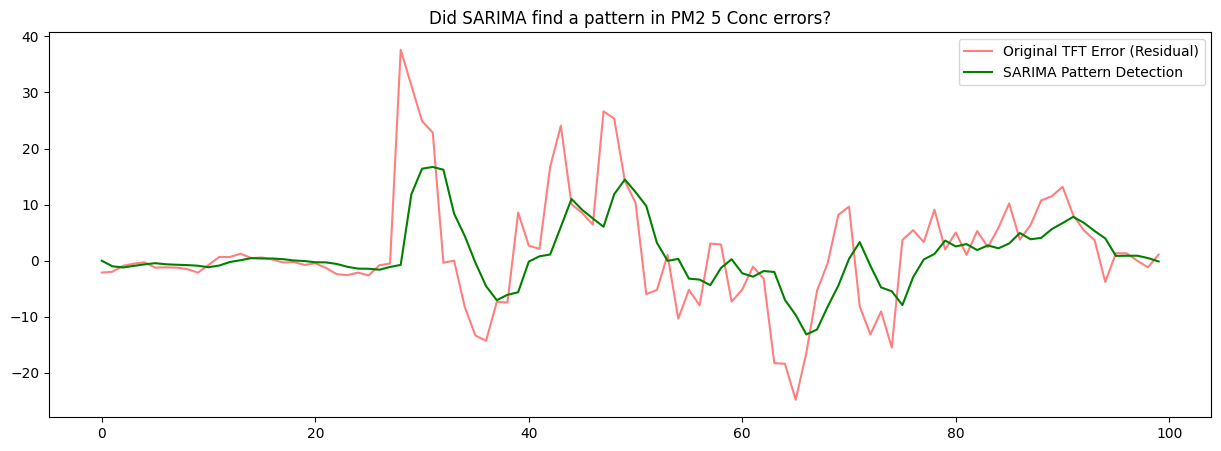

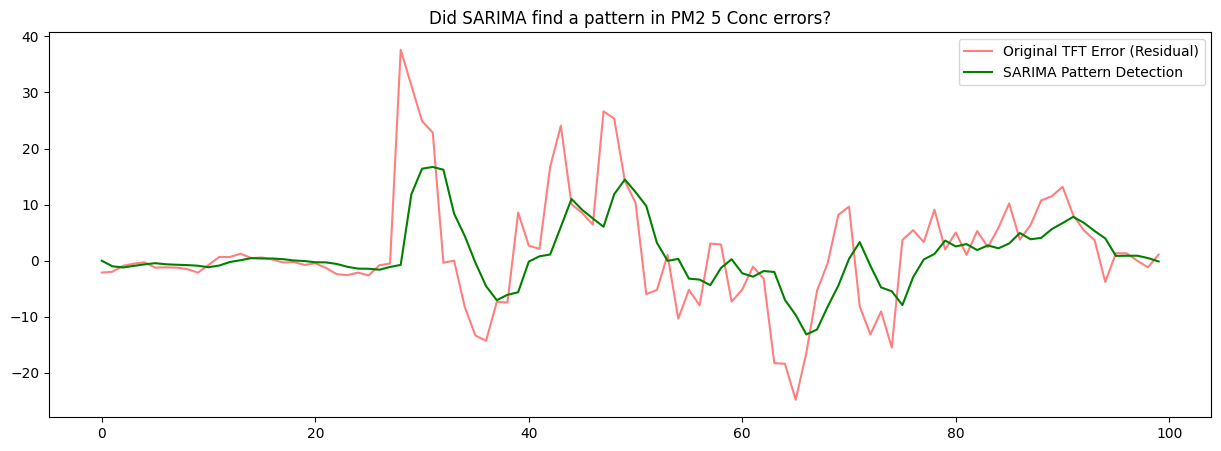

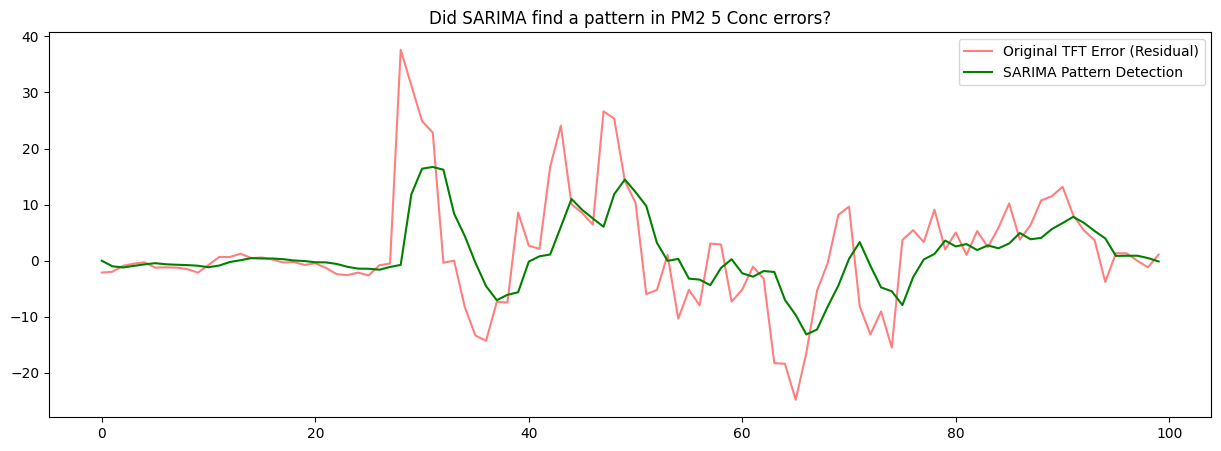

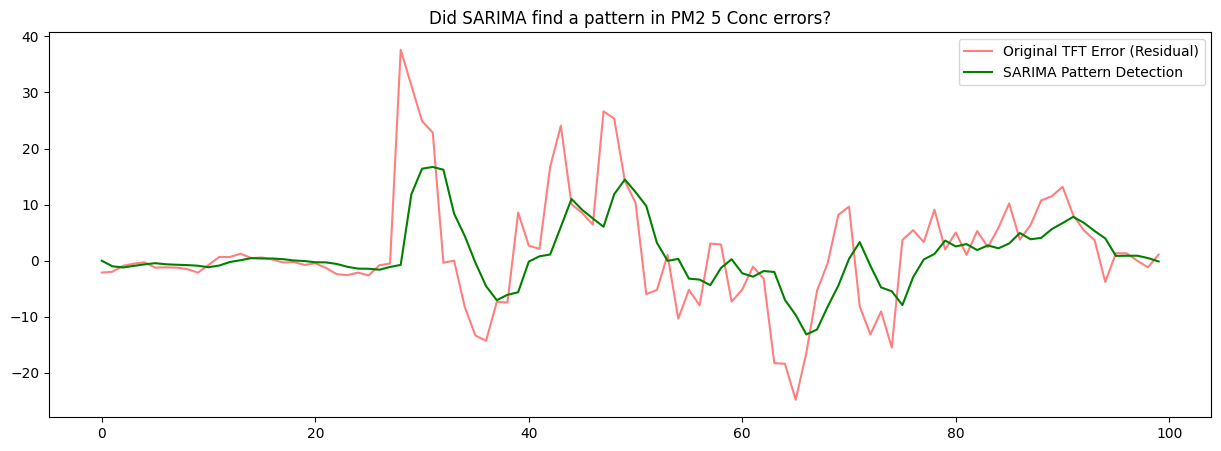

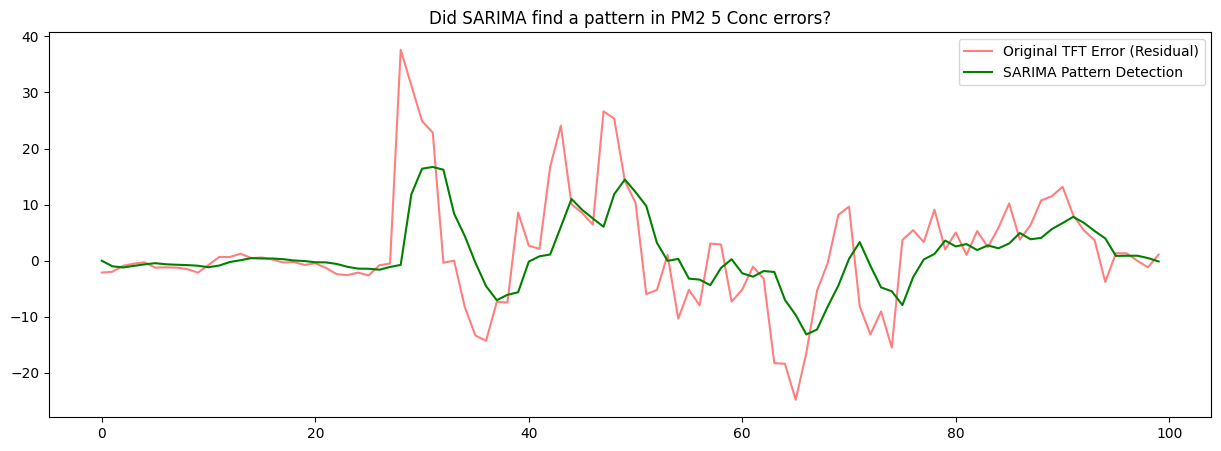

In [ ]:
for i in range(5):
    target_idx = 0
    target_name = TARGETS[target_idx]

    # Get  TFT error
    original_error = long_residuals[:, target_idx]

    # SARIMA predicts for this error
    sarima_correction = sarima_models[target_name].predict_in_sample()

    plt.figure(figsize=(15, 5))
    plt.plot(original_error[:100], label='Original TFT Error (Residual)', color='red', alpha=0.5)
    plt.plot(sarima_correction[:100], label='SARIMA Pattern Detection', color='green')
    plt.title(f"Did SARIMA find a pattern in {target_name} errors?")
    plt.legend()
    plt.show()

## TFT + LightGBM

### Train LightGBM

In [ ]:
HISTORY_DAYS = 30

In [ ]:
LGB_FEATURES = [
    'AT', 'RH', 'BP', 'Solar Rad', 'Rain Gauge',
    'WD_sin', 'WD_cos',
    'hour', 'day_of_week', 'month',
    'is_weekend', 'is_holiday',
    'Traffic_Stagnation',
    'Heat_Humidity_Interaction',
    'PM2 5 Conc_lag24', 'PM10 Conc_lag24',
    'monsoon_phase_First Inter-monsoon', 'monsoon_phase_Northeast Monsoon',
    'monsoon_phase_Second Inter-monsoon', 'monsoon_phase_Southwest Monsoon'
]

In [ ]:
# Select the last 30 days of data for training the corrector
history_steps = HISTORY_DAYS * 24
cutoff_start = df['time_idx'].max() - history_steps - (7*24)
history_data = df[lambda x: x.time_idx >= cutoff_start].copy()

In [ ]:
# 2. Create a Rolling Dataset
residual_dataset = TimeSeriesDataSet.from_dataset(
    training,
    history_data,
    predict=False,
    stop_randomization=True
)

In [ ]:
residual_dataloader = residual_dataset.to_dataloader(train=False, batch_size=256, num_workers=2)

In [ ]:
# Get Predictions from TFT
raw_predictions, x, index, *ignored = tft.predict(
    residual_dataloader,
    mode="raw",
    return_x=True,
    return_index=True
)

INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


In [ ]:
# Extract Data (Tensors -> Numpy)
tft_preds_tensor = torch.stack([p[..., 3] for p in raw_predictions['prediction']], dim=-1)

In [ ]:
# Actual Values
actuals_tensor = x['decoder_target']
if isinstance(actuals_tensor, list):
    actuals_tensor = torch.stack(actuals_tensor, dim=-1)

In [ ]:
# Flatten: We only care about the FIRST step of every prediction window for training
tft_series = tft_preds_tensor[:, 0, :].detach().cpu().numpy()
actual_series = actuals_tensor[:, 0, :].detach().cpu().numpy()
time_index_series = index['time_idx'].values

In [ ]:
# 5. Calculate Residuals (TARGET for LightGBM)
residuals = actual_series - tft_series

In [ ]:
residuals.shape

(698, 6)

In [ ]:
X_aligned = df[df['time_idx'].isin(time_index_series)].copy()

In [ ]:
# Helper function to convert "True"/"False"/"0"/"1" strings to integers
def clean_bool_col(series):
    # Convert to string first to handle Categorical objects
    s = series.astype(str)
    # Map common boolean strings to numbers
    return s.map({
        'True': 1, 'False': 0,
        '1': 1, '0': 0,
        '1.0': 1, '0.0': 0
    }).fillna(0).astype(int)

In [ ]:
bool_fix_cols = ['is_weekend', 'is_holiday', 'is_covid_lockdown', 'Low_Activity_Zone']

In [ ]:
bool_fix_cols += [c for c in X_aligned.columns if 'monsoon_phase' in c]

In [ ]:
for col in bool_fix_cols:
    if col in X_aligned.columns:
        X_aligned[col] = clean_bool_col(X_aligned[col])

In [ ]:
time_fix_cols = ['hour', 'day_of_week', 'month', 'traffic_hour']
for col in time_fix_cols:
    if col in X_aligned.columns:
        X_aligned[col] = X_aligned[col].astype(str).astype(float).astype(int)

In [ ]:
X_aligned = X_aligned.set_index('time_idx').reindex(time_index_series).reset_index()

In [ ]:
X_base = X_aligned[LGB_FEATURES].values.astype(np.float32)

In [ ]:
X_base.shape

(698, 20)

#### Train

In [ ]:
lgb_models = {}

In [ ]:
for i, target in enumerate(TARGETS):
    print(target)

    # Get the TFT prediction column for this specific pollutant
    tft_pred_col = tft_series[:, i].reshape(-1, 1)

    # Combine: [Context Features] + [TFT Prediction]
    X_train_final = np.hstack([X_base, tft_pred_col])

    # Get Target (The Residual for this pollutant)
    y_train_resid = residuals[:, i]

    # Train LightGBM
    model = lgb.LGBMRegressor(
        n_estimators=150,
        learning_rate=0.05,
        max_depth=5,
        num_leaves=20,
        objective='regression',
        n_jobs=-1,
        verbosity=-1
    )

    model.fit(X_train_final, y_train_resid)
    lgb_models[target] = model

PM2 5 Conc
PM10 Conc
SO2 Conc
NO2 Conc
O3 Conc
CO Conc


#### Evalutions

In [ ]:
TEST_DAYS = 7
TEST_HOURS = TEST_DAYS * 24

In [ ]:
encoder_len = training.max_encoder_length

In [ ]:
cutoff_test = df['time_idx'].max() - TEST_HOURS - encoder_len

In [ ]:
test_data = df[lambda x: x.time_idx > cutoff_test].copy()

In [ ]:
test_dataset = TimeSeriesDataSet.from_dataset(
    training,
    test_data,
    predict=True,
    stop_randomization=True
)

In [ ]:
test_dataloader = test_dataset.to_dataloader(train=False, batch_size=256, num_workers=2)

In [ ]:
raw_predictions, x, index, *ignored = tft.predict(
    test_dataloader,
    mode="raw",
    return_x=True,
    return_index=True
)

INFO: 💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelCheckpoint, which syncs automatically with the Lightning model registry.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


In [ ]:
# Extract Mean Prediction and Actuals
tft_base_preds = torch.stack([p[..., 3] for p in raw_predictions['prediction']], dim=-1).cpu().numpy()

In [ ]:
actuals = x['decoder_target']
if isinstance(actuals, list):
    actuals = torch.stack(actuals, dim=-1)
actuals = actuals.cpu().numpy()

In [ ]:
# Prepare Features for LightGBM
pred_time_indices = index['time_idx'].values

In [ ]:
# Filter & Align Context Features
X_test_aligned = df[df['time_idx'].isin(pred_time_indices)].copy()

In [ ]:
def clean_bool_col(series):
    s = series.astype(str)
    return s.map({
        'True': 1, 'False': 0,
        '1': 1, '0': 0,
        '1.0': 1, '0.0': 0
    }).fillna(0).astype(int)

In [ ]:
for col in ['is_weekend', 'is_holiday', 'is_covid_lockdown', 'Low_Activity_Zone']:
    if col in X_test_aligned.columns:
        X_test_aligned[col] = clean_bool_col(X_test_aligned[col])

In [ ]:
for col in ['hour', 'day_of_week', 'month', 'traffic_hour']:
    if col in X_test_aligned.columns:
        X_test_aligned[col] = X_test_aligned[col].astype(str).astype(float).astype(int)

In [ ]:
# Reindex to match the prediction order exactly
X_test_aligned = X_test_aligned.set_index('time_idx').reindex(pred_time_indices).reset_index()

In [ ]:
X_test_base = X_test_aligned[LGB_FEATURES].values.astype(np.float32)

In [ ]:
# Calculate Hybrid Output
hybrid_preds = tft_base_preds.copy()

In [ ]:
for i, target in enumerate(TARGETS):
    # Construct Input: [Context] + [TFT_Base_Prediction_Level]
    tft_level = tft_base_preds[:, :, i].mean(axis=1).reshape(-1, 1)

    X_input = np.hstack([X_test_base, tft_level])

    # Predict Bias (Residual)
    bias = lgb_models[target].predict(X_input)

    # Hybrid = Base + Bias
    hybrid_preds[:, :, i] += bias[:, None]

In [ ]:
metrics_list = []

In [ ]:
for i, pollutant_name in enumerate(TARGETS):
    # Flatten arrays for global evaluation (all test windows combined)
    y_true = actuals[:, :, i].flatten()
    y_base = tft_base_preds[:, :, i].flatten()
    y_hybrid = hybrid_preds[:, :, i].flatten()

    # Calculate Metrics
    rmse_base = np.sqrt(mean_squared_error(y_true, y_base))
    rmse_hybrid = np.sqrt(mean_squared_error(y_true, y_hybrid))

    mae_base = mean_absolute_error(y_true, y_base)
    mae_hybrid = mean_absolute_error(y_true, y_hybrid)

    r2_val = r2_score(y_true, y_hybrid)

    # Calculate Improvement %
    imp_rmse = ((rmse_base - rmse_hybrid) / rmse_base) * 100 if rmse_base > 0 else 0.0
    imp_mae = ((mae_base - mae_hybrid) / mae_base) * 100 if mae_base > 0 else 0.0

    metrics_list.append({
        "Pollutant": pollutant_name,
        "Base RMSE": round(rmse_base, 2),
        "Hybrid RMSE": round(rmse_hybrid, 2),
        "RMSE Imp": f"{imp_rmse:.1f}%",
        "Base MAE": round(mae_base, 2),
        "Hybrid MAE": round(mae_hybrid, 2),
        "MAE Imp": f"{imp_mae:.1f}%",
        "Hybrid R2": f"{r2_val:.3f}"
    })

In [ ]:
if len(metrics_list) > 0:
    scorecard_df = pd.DataFrame(metrics_list).set_index("Pollutant")
    print(scorecard_df.sort_values("RMSE Imp", ascending=False).to_string())
else:
    print("Report is empty.")

            Base RMSE  Hybrid RMSE RMSE Imp  Base MAE  Hybrid MAE MAE Imp Hybrid R2
Pollutant                                                                          
NO2 Conc         9.23         7.42    19.6%      8.43        6.40   24.1%    -4.585
O3 Conc          7.22         5.82    19.4%      5.24        5.25   -0.3%   -45.130
PM2 5 Conc      20.97        18.69    10.9%     20.19       17.92   11.2%    -4.936
PM10 Conc       34.85        36.69    -5.3%     33.61       35.42   -5.4%    -7.418
SO2 Conc         1.42         1.67   -17.5%      1.31        1.57  -20.3%    -5.766
CO Conc       2119.80      2142.76    -1.1%   1890.60     1910.42   -1.0%    -2.044
